# Veri Madenciliği Projesi
## Açıklayıcı Veri Analizi (EDA) + Özellik Mühendesliği (Feature Engineering) + Hedef Değişken Oluşturma
**Veri Seti:** `edm_2023.csv`  
**Amaç:** Öğrenci başarı seviyesinin çok sınıflı sınıflandırma ile tahmini

---
# BÖLÜM 1 — Ham Veri Araştırma (EDA)
## 1.1 Kütüphanelerin Yüklenmesi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)

print('Tüm kütüphaneler başarıyla yüklendi.')

Tüm kütüphaneler başarıyla yüklendi.


## 1.2 Veri Yükleme ve İlk Bakış

In [2]:
df = pd.read_csv('edm_2023.csv')

print('='*60)
print('VERİ SETİ BOYUTU')
print('='*60)
print(f'Satır sayısı  : {df.shape[0]:,}')
print(f'Sütun sayısı  : {df.shape[1]}')
print(f'Toplam hücre  : {df.shape[0] * df.shape[1]:,}')
print('\n' + '='*60)
print('İLK 5 SATIR')
print('='*60)
df.head()

VERİ SETİ BOYUTU
Satır sayısı  : 1,745,977
Sütun sayısı  : 26
Toplam hücre  : 45,395,402

İLK 5 SATIR


,assignment_log_id,teacher_id,class_id,student_id,sequence_id,assignment_release_date,assignment_due_date,assignment_start_time,assignment_end_time,sequence_folder_path_level_1,...,timestamp,problem_id,max_attempts,available_core_tutoring,score_viewable,continuous_score_viewable,action,hint_id,explanation_id,score
0,1L60X9CLMJ,13FM9BH12Z,2K6V6GTPMC,1O4U5A5XC0,1W2GHS3F0O,1.581348e+09,1.582060e+09,1.581356e+09,1.581356e+09,EngageNY/Eureka Math (© by Great Minds®) *,...,1.581356e+09,JSD9N8SNS,1.0,no_tutoring,1.0,0.0,problem_started,NaN,NaN,1
1,1L60X9CLMJ,13FM9BH12Z,2K6V6GTPMC,1O4U5A5XC0,1W2GHS3F0O,1.581348e+09,1.582060e+09,1.581356e+09,1.581356e+09,EngageNY/Eureka Math (© by Great Minds®) *,...,1.581356e+09,JSD9N8SNS,1.0,no_tutoring,1.0,0.0,problem_started,NaN,NaN,1
2,1L60X9CLMJ,13FM9BH12Z,2K6V6GTPMC,1O4U5A5XC0,1W2GHS3F0O,1.581348e+09,1.582060e+09,1.581356e+09,1.581356e+09,EngageNY/Eureka Math (© by Great Minds®) *,...,1.581356e+09,JSD9N8SNS,1.0,no_tutoring,1.0,0.0,problem_started,NaN,NaN,1
3,1L60X9CLMJ,13FM9BH12Z,2K6V6GTPMC,1O4U5A5XC0,1W2GHS3F0O,1.581348e+09,1.582060e+09,1.581356e+09,1.581356e+09,EngageNY/Eureka Math (© by Great Minds®) *,...,1.581356e+09,JSD9N8SNS,NaN,NaN,NaN,NaN,open_response,NaN,NaN,1
4,1L60X9CLMJ,13FM9BH12Z,2K6V6GTPMC,1O4U5A5XC0,1W2GHS3F0O,1.581348e+09,1.582060e+09,1.581356e+09,1.581356e+09,EngageNY/Eureka Math (© by Great Minds®) *,...,1.581356e+09,JSD9N8SNS,NaN,NaN,NaN,NaN,open_response,NaN,NaN,1


In [3]:
# Rastgele 5 satırı ekrana yazdıracağız
df.sample(5, random_state=42)

,assignment_log_id,teacher_id,class_id,student_id,sequence_id,assignment_release_date,assignment_due_date,assignment_start_time,assignment_end_time,sequence_folder_path_level_1,...,timestamp,problem_id,max_attempts,available_core_tutoring,score_viewable,continuous_score_viewable,action,hint_id,explanation_id,score
1190226,1KL6UH2POS,23ZQUWTVNJ,9LMOU6BN9,MSG8XM12Q,22U938JXKH,1.581349e+09,NaN,1.581355e+09,1.581356e+09,EngageNY/Eureka Math (© by Great Minds®) *,...,1.581356e+09,16RKTEFAWK,NaN,NaN,NaN,NaN,problem_finished,NaN,NaN,1
1327227,27XTV8PK5V,GCO8EQG9J,U4JCLW5NX,1O7990OPX4,987IRAKF0,1.584976e+09,1.585366e+09,1.584976e+09,1.584978e+09,EngageNY/Eureka Math (© by Great Minds®) *,...,1.584976e+09,1MTOE93H2O,3.0,hint,1.0,1.0,problem_started,NaN,NaN,1
1119976,LUQ4C4QXK,113AKPXCRW,5ON6I6SQK,BHTBZILHR,H8SQ1X375,1.585160e+09,1.585247e+09,1.585163e+09,1.585232e+09,EngageNY/Eureka Math (© by Great Minds®) *,...,1.585231e+09,1N4PVI6EYU,NaN,NaN,NaN,NaN,correct_response,NaN,NaN,1
1167043,1W2B074X,1FY7XU4RZ8,54YKVMBSV,2OW5KQ7IQ8,6B8HVKNLO,1.581697e+09,1.581956e+09,1.581697e+09,NaN,EngageNY/Eureka Math (© by Great Minds®) *,...,1.581699e+09,1WGM2O3JR7,NaN,NaN,NaN,NaN,correct_response,NaN,NaN,1
81249,25E2W4VG0C,13FM9BH12Z,1URCISUTFA,2L5QKP44EH,2RBQCXZZXS,1.578492e+09,1.578949e+09,1.578602e+09,1.578603e+09,EngageNY/Eureka Math (© by Great Minds®) *,...,1.578602e+09,1E20KFZ07B,3.0,answer,1.0,1.0,problem_started,NaN,NaN,1


## 1.3 Sütun Adları, Veri Tipleri ve Meta-data

In [4]:
print('SÜTUN ADLARI')
for i, col in enumerate(df.columns, 1):
    print(f'{i:>3}. {col}')


print('VERİ TİPLERİ VE BELLEK KULLANIMI')
df.info(memory_usage='deep')

# Sayısal / kategorik ayrımı — ham veri için
numeric_cols_raw     = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_raw = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'\nSayısal sütun sayısı   : {len(numeric_cols_raw)}')
print(f'Kategorik sütun sayısı : {len(categorical_cols_raw)}')

SÜTUN ADLARI
  1. assignment_log_id
  2. teacher_id
  3. class_id
  4. student_id
  5. sequence_id
  6. assignment_release_date
  7. assignment_due_date
  8. assignment_start_time
  9. assignment_end_time
 10. sequence_folder_path_level_1
 11. sequence_folder_path_level_2
 12. sequence_folder_path_level_3
 13. sequence_folder_path_level_4
 14. sequence_folder_path_level_5
 15. sequence_name
 16. sequence_problem_ids
 17. timestamp
 18. problem_id
 19. max_attempts
 20. available_core_tutoring
 21. score_viewable
 22. continuous_score_viewable
 23. action
 24. hint_id
 25. explanation_id
 26. score
VERİ TİPLERİ VE BELLEK KULLANIMI
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1745977 entries, 0 to 1745976
Data columns (total 26 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   assignment_log_id             object 
 1   teacher_id                    object 
 2   class_id                      object 
 3   student_id                   

## 1.4 İstatistiksel Özet

In [5]:
print('SAYISAL SÜTUNLAR — İSTATİSTİKSEL ÖZET')
df.describe().T.style.background_gradient(cmap='Blues')

SAYISAL SÜTUNLAR — İSTATİSTİKSEL ÖZET


,count,mean,std,min,25%,50%,75%,max
assignment_release_date,1745977.000000,1580130227.166722,6936238.575495,1551122439.786000,1579016032.024000,1581514800.000000,1584936000.000000,1585316984.747000
assignment_due_date,1032645.000000,1579548574.710690,8683247.835634,1551122520.000000,1576709040.000000,1582742220.000000,1585167720.000000,1591367280.000000
assignment_start_time,1745977.000000,1580208657.751863,6939146.210547,1551122457.474000,1579027591.106000,1581533802.433000,1584977662.651000,1585317806.413000
assignment_end_time,1551377.000000,1580342843.872131,7275615.572186,1551200806.307000,1579185136.196000,1582642075.284000,1585057496.656000,1593010088.412000
sequence_folder_path_level_5,0.000000,nan,nan,nan,nan,nan,nan,nan
timestamp,1745977.000000,1580262843.975586,6956586.885962,1551122458.271000,1579098818.969000,1581544184.878000,1584991836.218000,1593010088.365000
max_attempts,452443.000000,2.536720,0.843762,1.000000,3.000000,3.000000,3.000000,3.000000
score_viewable,452443.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
continuous_score_viewable,452443.000000,0.768360,0.421881,0.000000,1.000000,1.000000,1.000000,1.000000
explanation_id,0.000000,nan,nan,nan,nan,nan,nan,nan


In [6]:
if categorical_cols_raw:
    print('KATEGORİK SÜTUNLAR — ÖZET')
    display(df[categorical_cols_raw].describe())

KATEGORİK SÜTUNLAR — ÖZET


,assignment_log_id,teacher_id,class_id,student_id,sequence_id,sequence_folder_path_level_1,sequence_folder_path_level_2,sequence_folder_path_level_3,sequence_folder_path_level_4,sequence_name,sequence_problem_ids,problem_id,available_core_tutoring,action,hint_id
count,1745977,1745977,1745977,1745977,1745977,1745977,1745977,1745977,1745977,1745977,1745977,1745977,452443,1745977,477
unique,15468,95,127,1499,670,2,9,39,236,670,670,7062,3,7,19
top,1HWS1GDHSY,2D7TTJJY0I,1H75ZHRGLE,N2D0LL79R,1AI4XFZWJB,EngageNY/Eureka Math (© by Great Minds®) *,Grade 5,Module 4 - Multiplying and Dividing Fractions ...,Topic G---Lesson 29,Problem Set---5.4 Lesson 29 (5.NF.B.7.B),"[OF3H9QYHO,ZWJ2MKSO7,1HHCT3KTPD,IHMIUUP1R,S0DN...",BDK6554UI,answer,problem_started,1OREQZIZKZ
freq,7123,362792,148297,16986,36465,1703080,828563,697993,60314,36465,36465,8316,187045,452443,108


## 1.5 Eksik Değer Analizi

In [7]:
missing = pd.DataFrame({
    'Eksik Sayısı'   : df.isnull().sum(),
    'Eksik Yüzdesi %': (df.isnull().sum() / len(df) * 100).round(2),
    'Veri Tipi'      : df.dtypes
}).sort_values('Eksik Sayısı', ascending=False)


print('EKSİK DEĞER TABLOSU (Sadece eksik olanlar)')
display(missing[missing['Eksik Sayısı'] > 0])
print(f'Toplam {df.isnull().sum().sum():,} eksik değer mevcut.')

EKSİK DEĞER TABLOSU (Sadece eksik olanlar)


,Eksik Sayısı,Eksik Yüzdesi %,Veri Tipi
sequence_folder_path_level_5,1745977,100.00,float64
explanation_id,1745977,100.00,float64
hint_id,1745500,99.97,object
continuous_score_viewable,1293534,74.09,float64
score_viewable,1293534,74.09,float64
available_core_tutoring,1293534,74.09,object
max_attempts,1293534,74.09,float64
assignment_due_date,713332,40.86,float64
assignment_end_time,194600,11.15,float64


Toplam 11,319,522 eksik değer mevcut.


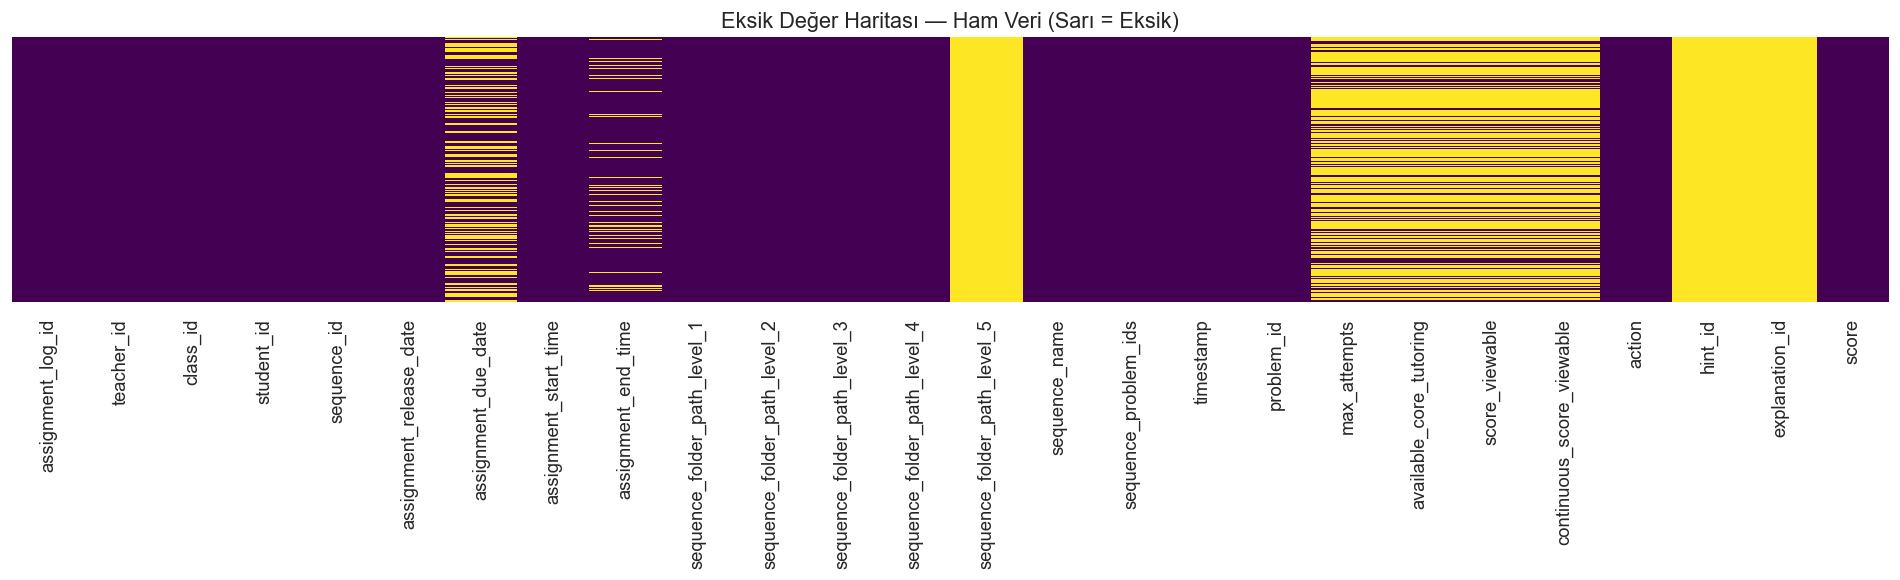

In [8]:
# Eksik değer ısı haritası
plt.figure(figsize=(16, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Eksik Değer Haritası — Ham Veri (Sarı = Eksik)', fontsize=13)
plt.tight_layout()
plt.show()

## 1.6 Tekrar Eden Satır Analizi

In [9]:
dup_total = df.duplicated().sum()
print('TEKRAR EDEN SATIRLAR')
print(f'Tüm sütunlar bazında duplicate : {dup_total:,} (%{dup_total/len(df)*100:.1f})')

# Log verisi mantığı — student+problem+action bazında
key_cols = [c for c in ['student_id', 'problem_id', 'action', 'timestamp'] if c in df.columns]
dup_key  = df.duplicated(subset=key_cols).sum()
print(f'student+problem+action+timestamp bazında : {dup_key:,} (%{dup_key/len(df)*100:.1f})')
print('Log verisi olduğundan duplicate\'lar kasıtlı olabilir.')
print('Aggregasyon sonrası bu sorun ortadan kalkacak.')

TEKRAR EDEN SATIRLAR
Tüm sütunlar bazında duplicate : 1,006,409 (%57.6)
student+problem+action+timestamp bazında : 1,293,536 (%74.1)
Log verisi olduğundan duplicate'lar kasıtlı olabilir.
Aggregasyon sonrası bu sorun ortadan kalkacak.


## 1.7 Action Sütunu — Log Yapısını Anla

ACTION SÜTUNU DAĞILIMI
action
problem_started     452443
problem_finished    448057
correct_response    344429
wrong_response      314085
open_response       103624
answer_requested     82862
hint_requested         477
Name: count, dtype: int64


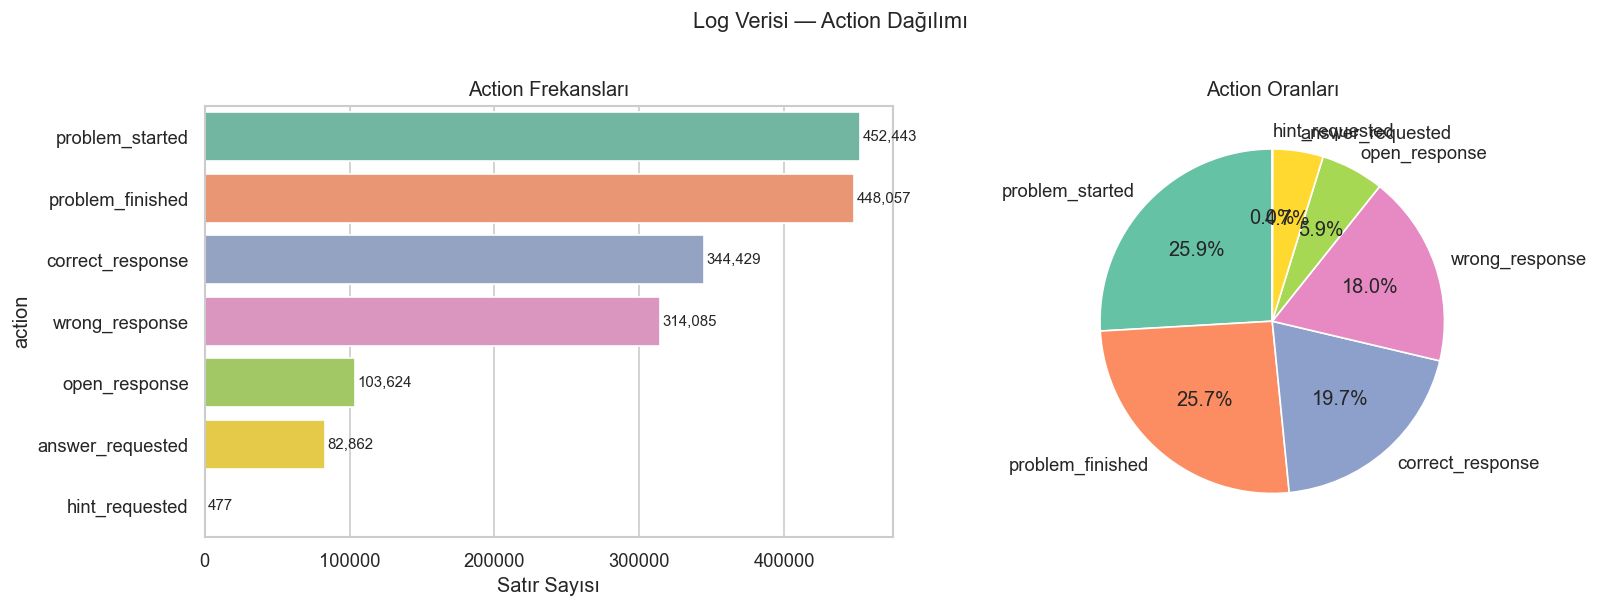

In [10]:
print('='*60)
print('ACTION SÜTUNU DAĞILIMI')
print('='*60)
action_vc = df['action'].value_counts()
print(action_vc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=action_vc.values, y=action_vc.index, ax=axes[0], palette='Set2')
axes[0].set_title('Action Frekansları', fontsize=12)
axes[0].set_xlabel('Satır Sayısı')
for i, v in enumerate(action_vc.values):
    axes[0].text(v + len(df)*0.001, i, f'{v:,}', va='center', fontsize=9)

axes[1].pie(action_vc.values, labels=action_vc.index,
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('Set2', len(action_vc)))
axes[1].set_title('Action Oranları', fontsize=12)
plt.suptitle('Log Verisi — Action Dağılımı', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 1.8 Score Sütunu — Ham Hedef Değişken

SCORE DAĞILIMI (Ham — Satır Bazında)
score
0     725734
1    1020243
Name: count, dtype: int64

Ortalama score : 0.5843
Score=1 oranı  : %58.4
Eksik score    : 0 satır


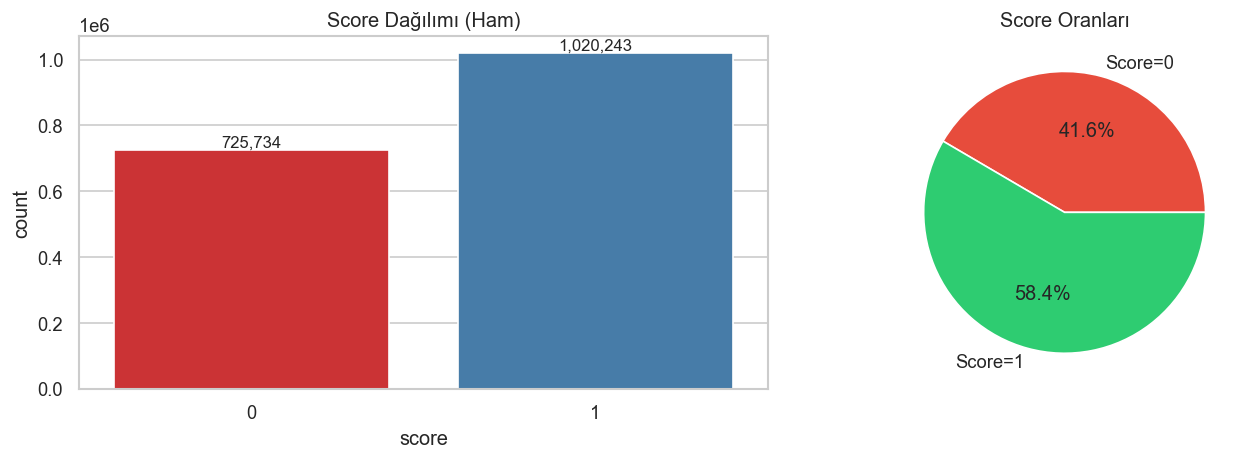

In [11]:
score_vc = df['score'].value_counts().sort_index()
print('SCORE DAĞILIMI (Ham — Satır Bazında)')
print(score_vc)
print(f'\nOrtalama score : {df["score"].mean():.4f}')
print(f'Score=1 oranı  : %{df["score"].mean()*100:.1f}')
print(f'Eksik score    : {df["score"].isnull().sum():,} satır')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='score', ax=axes[0], palette='Set1')
axes[0].set_title('Score Dağılımı (Ham)', fontsize=12)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

axes[1].pie(score_vc.values, labels=[f'Score={i}' for i in score_vc.index],
            autopct='%1.1f%%', colors=['#e74c3c','#2ecc71'])
axes[1].set_title('Score Oranları', fontsize=12)
plt.tight_layout()
plt.show()

## 1.9 Sayısal Değişken Dağılımları (Ham Veri)

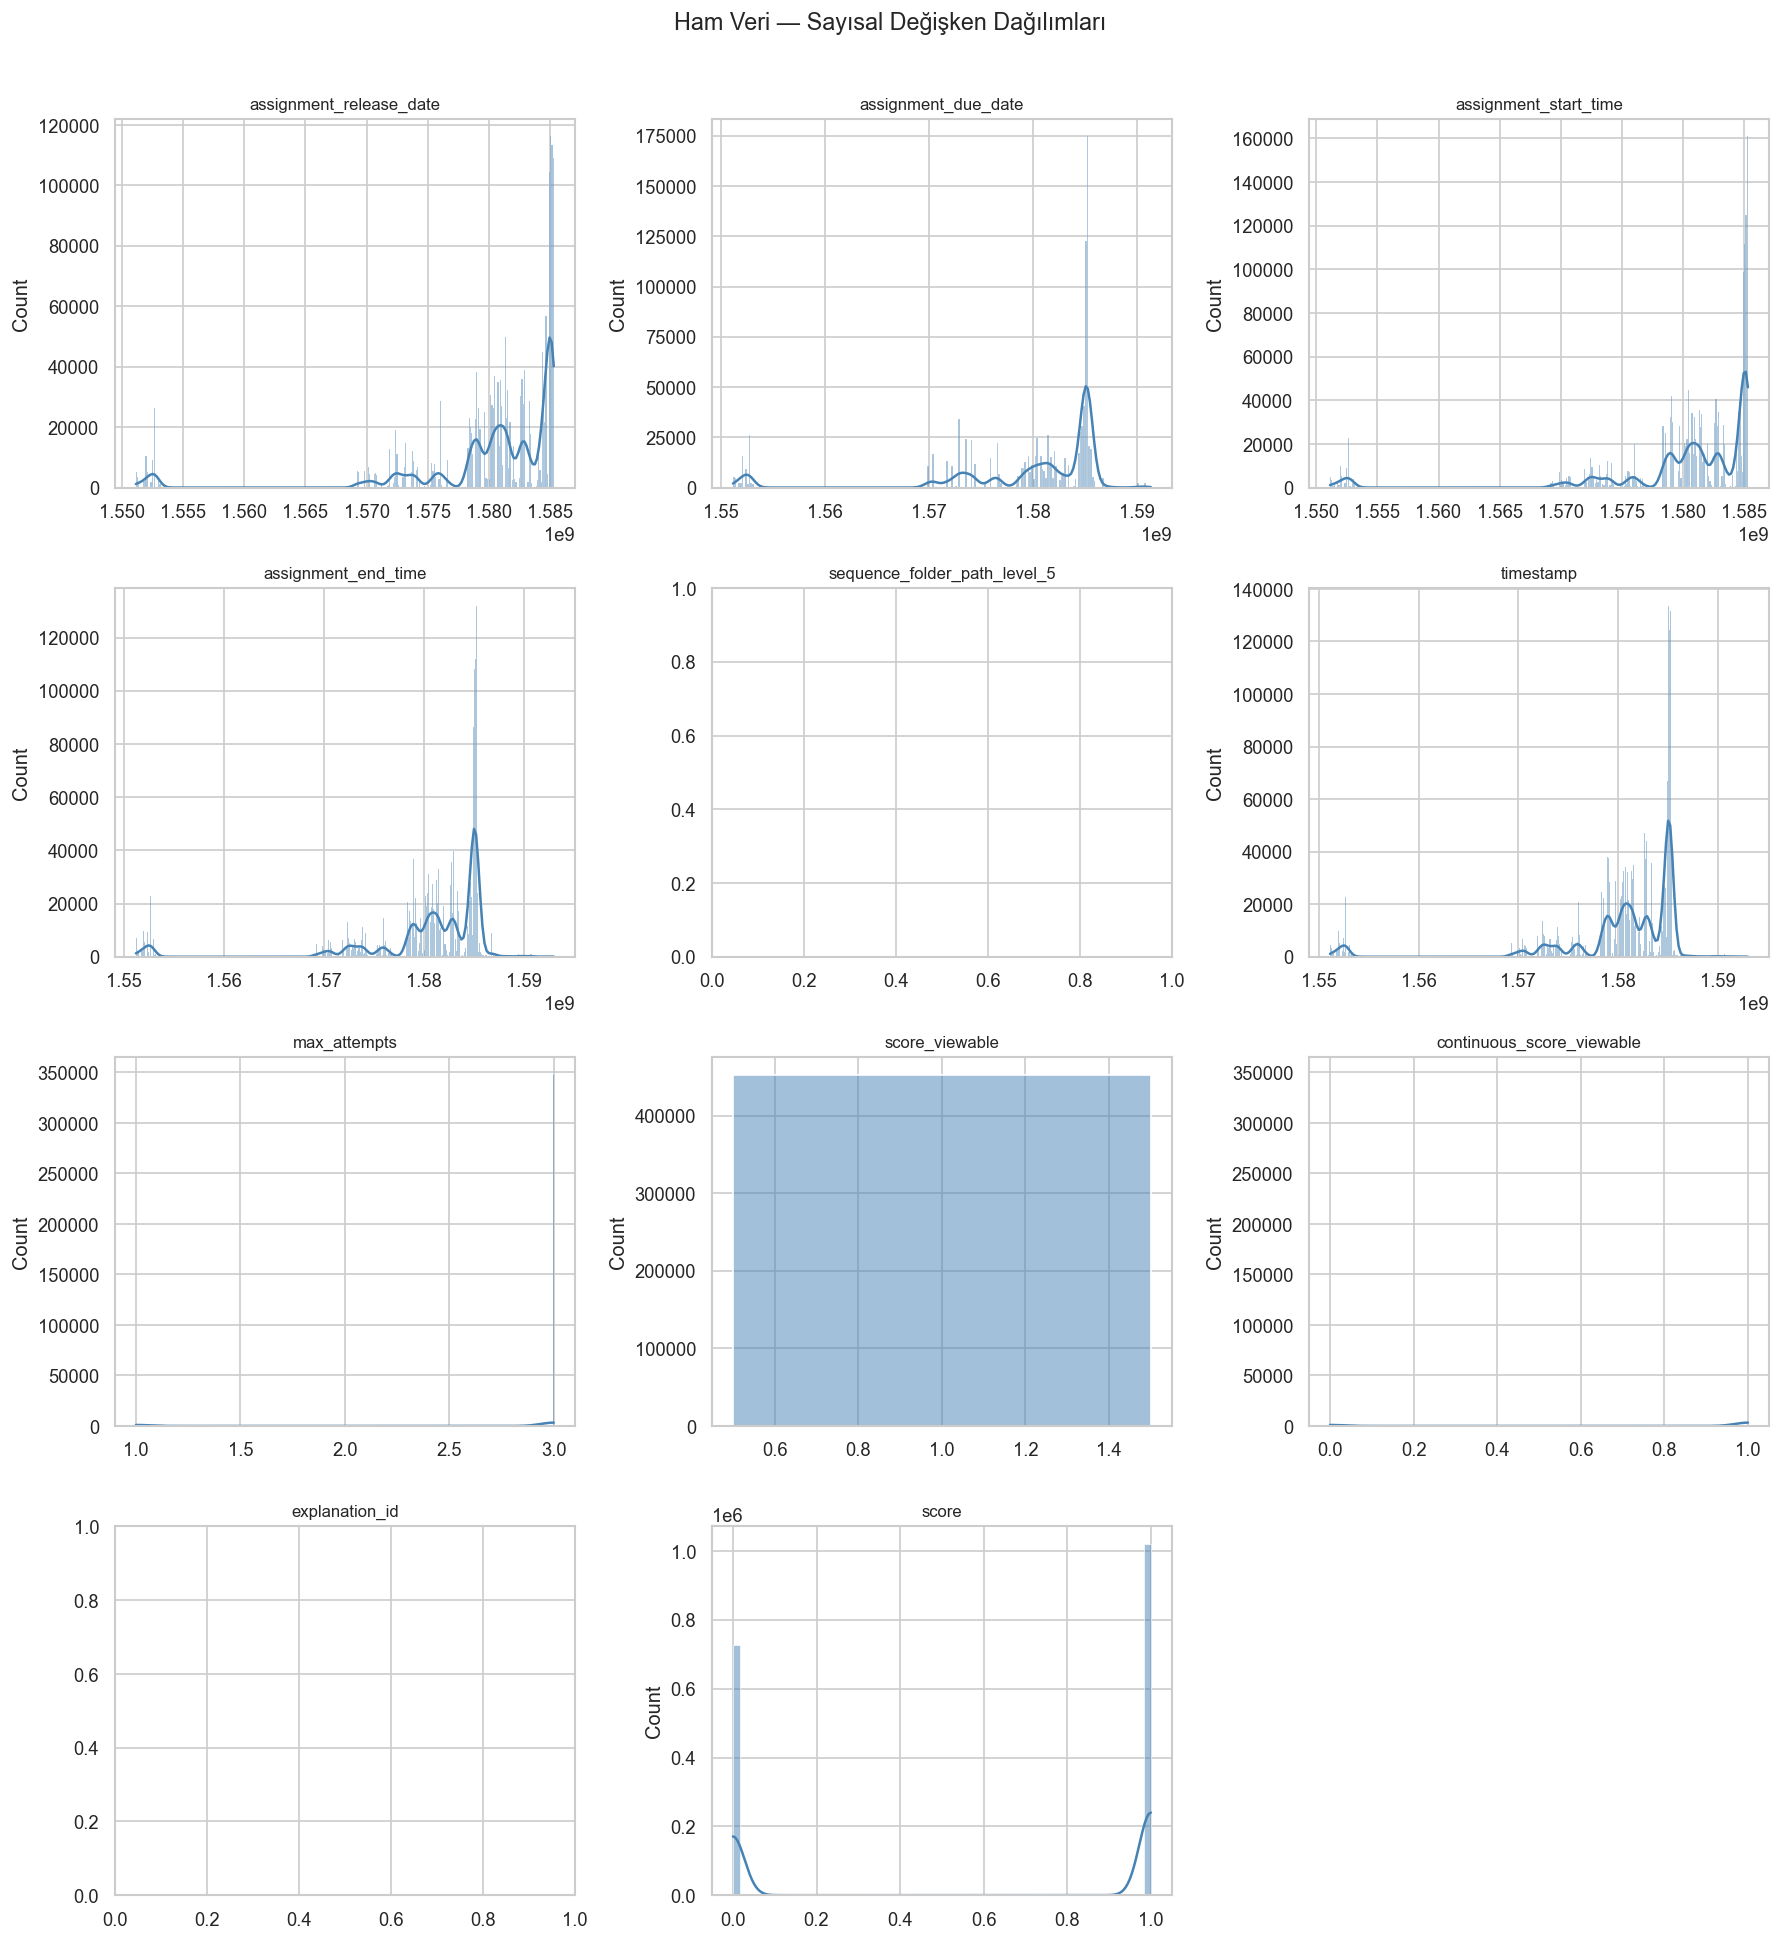

In [12]:
n = len(numeric_cols_raw)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row
fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row*5, rows*4))
axes = axes.flatten() if n > 1 else [axes]

for i, col in enumerate(numeric_cols_raw):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Ham Veri — Sayısal Değişken Dağılımları', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 1.10 Aykırı Değer Analizi (IQR)

IQR — AYKIRI DEĞER TABLOSU


,Sütun,Alt Sınır,Üst Sınır,Aykırı Sayısı,Aykırı %
0,assignment_release_date,1.570136e+09,1.593816e+09,94730,5.43
1,assignment_due_date,1.564021e+09,1.597856e+09,71888,4.12
2,assignment_start_time,1.570102e+09,1.593903e+09,87498,5.01
3,assignment_end_time,1.570377e+09,1.593866e+09,88536,5.07
4,sequence_folder_path_level_5,NaN,NaN,0,0.00
5,timestamp,1.570259e+09,1.593831e+09,91171,5.22
6,max_attempts,3.000000e+00,3.000000e+00,104804,6.00
7,score_viewable,1.000000e+00,1.000000e+00,0,0.00
8,continuous_score_viewable,1.000000e+00,1.000000e+00,104804,6.00
9,explanation_id,NaN,NaN,0,0.00


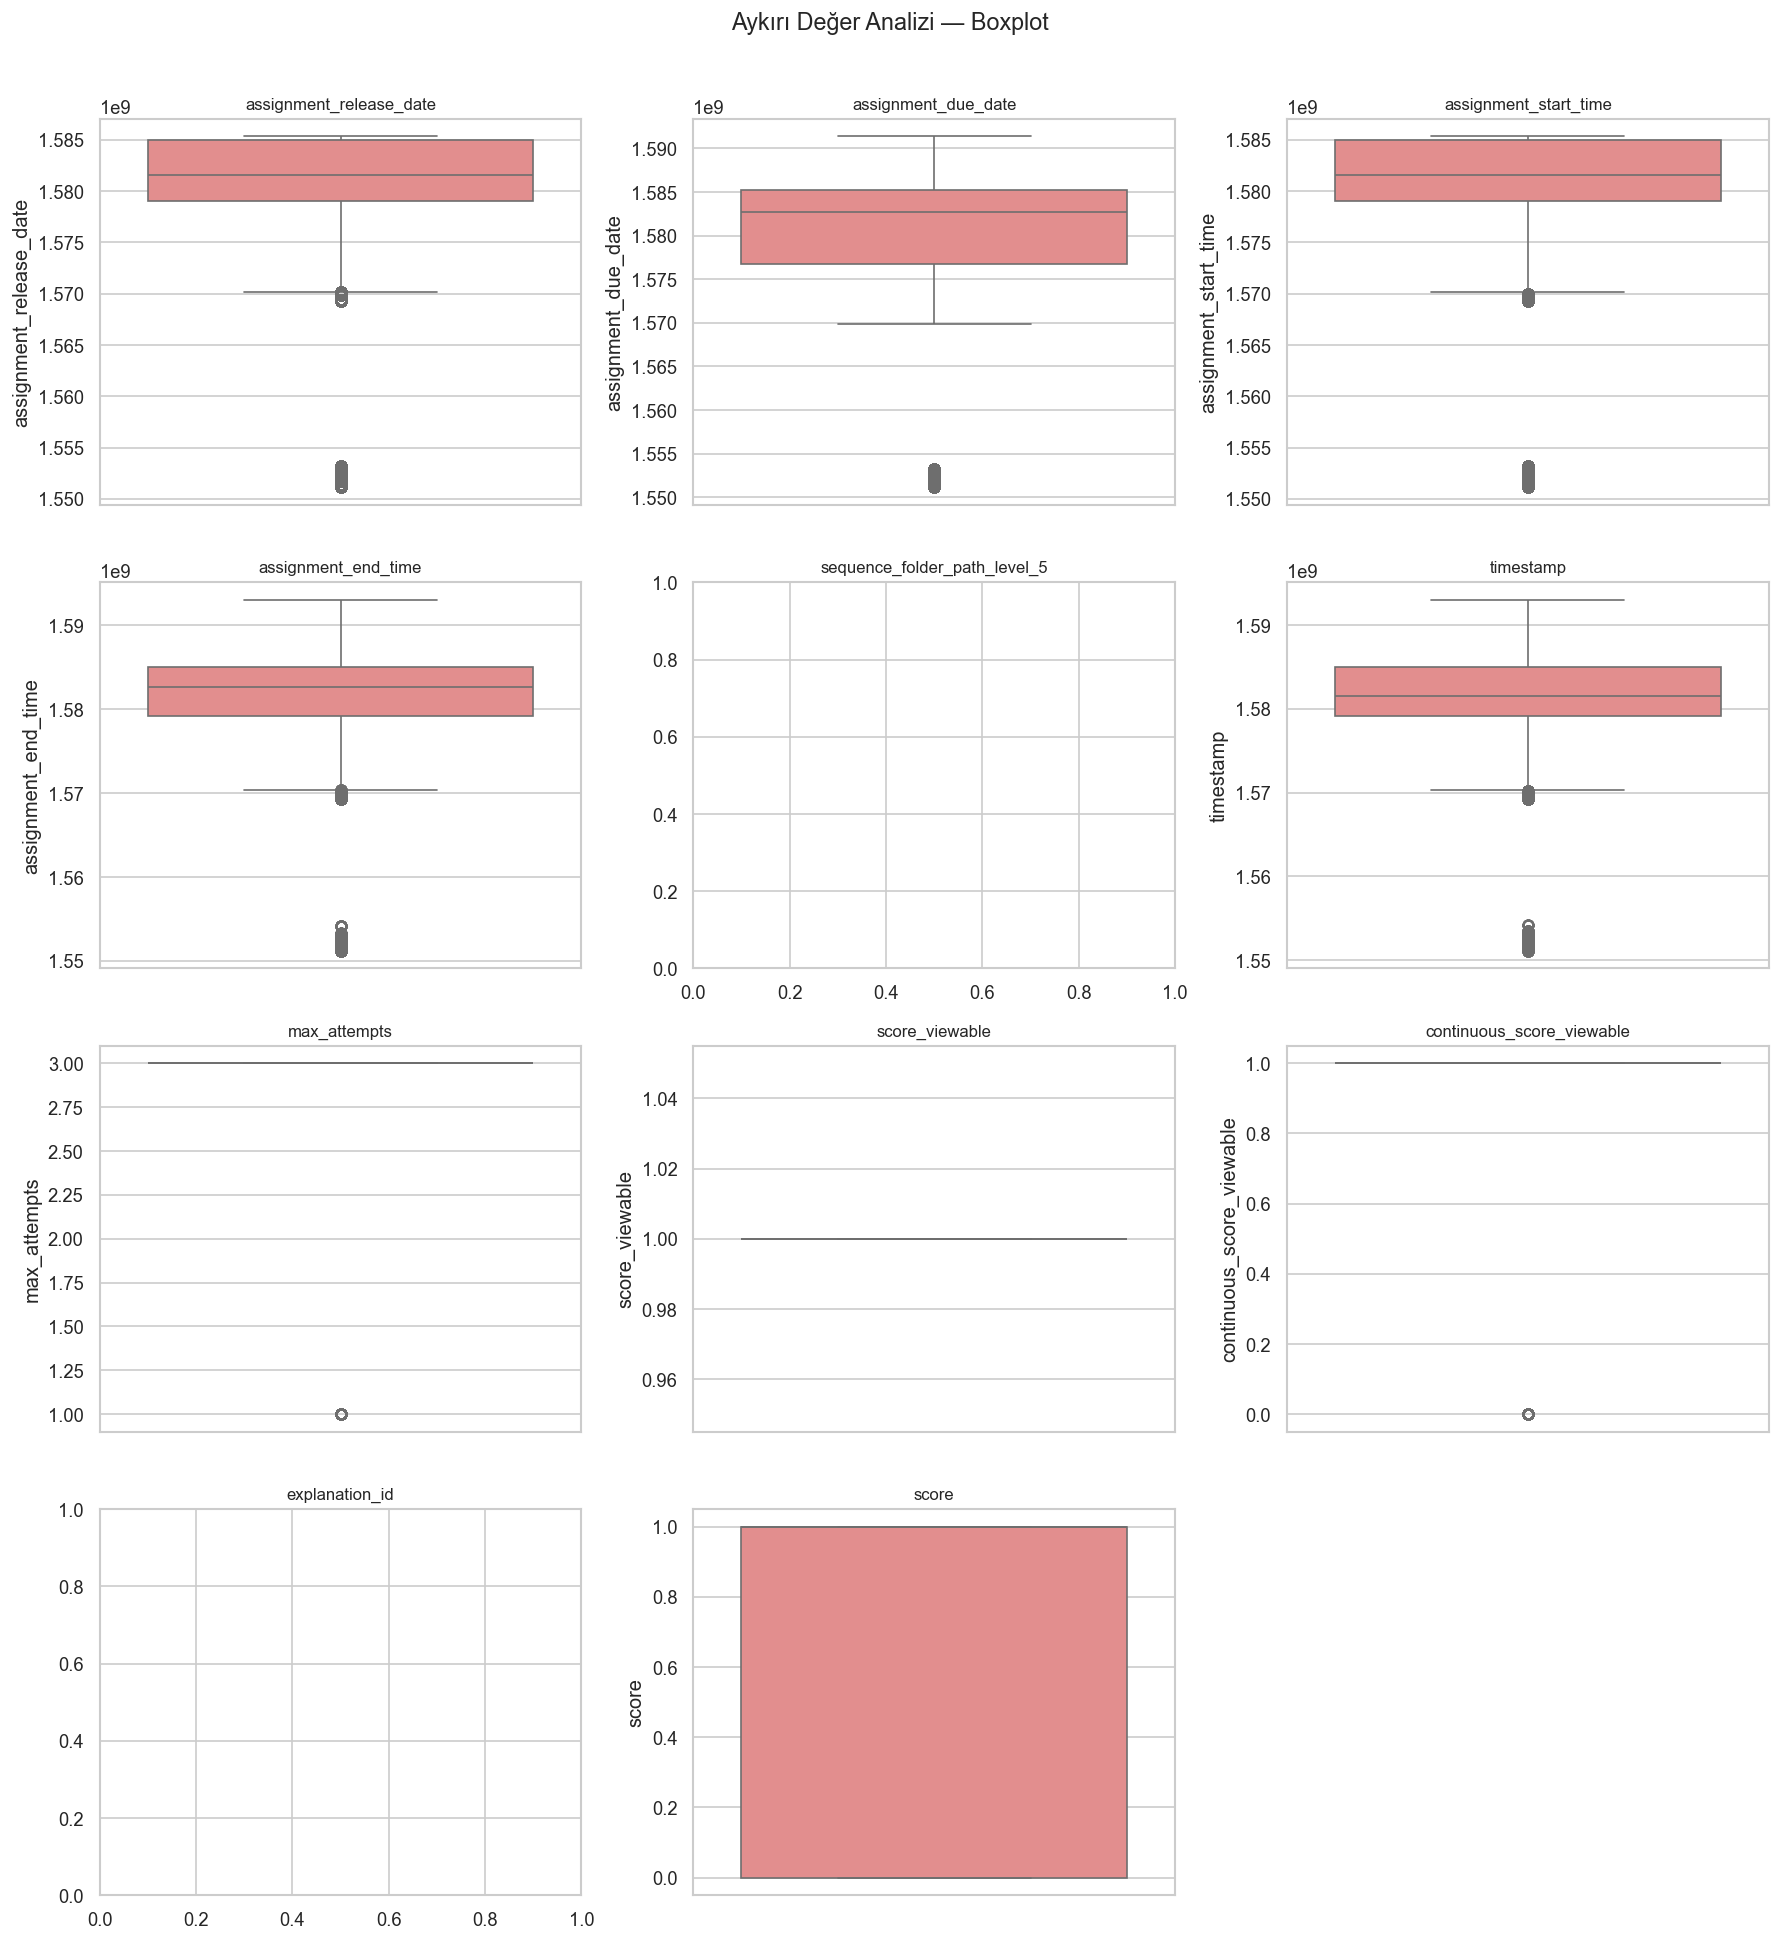

In [13]:
outlier_rows = []
for col in numeric_cols_raw:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append({'Sütun': col, 'Alt Sınır': round(lower,2),
                         'Üst Sınır': round(upper,2),
                         'Aykırı Sayısı': n_out,
                         'Aykırı %': round(n_out/len(df)*100, 2)})

outlier_df = pd.DataFrame(outlier_rows)
print('IQR — AYKIRI DEĞER TABLOSU')
display(outlier_df)

# Boxplot
n = len(numeric_cols_raw)
rows = (n + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(15, rows*4))
axes = axes.flatten() if n > 1 else [axes]
for i, col in enumerate(numeric_cols_raw):
    sns.boxplot(y=df[col].dropna(), ax=axes[i], color='lightcoral')
    axes[i].set_title(col, fontsize=10)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Aykırı Değer Analizi — Boxplot', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 1.11 Kategorik Değişken Analizi

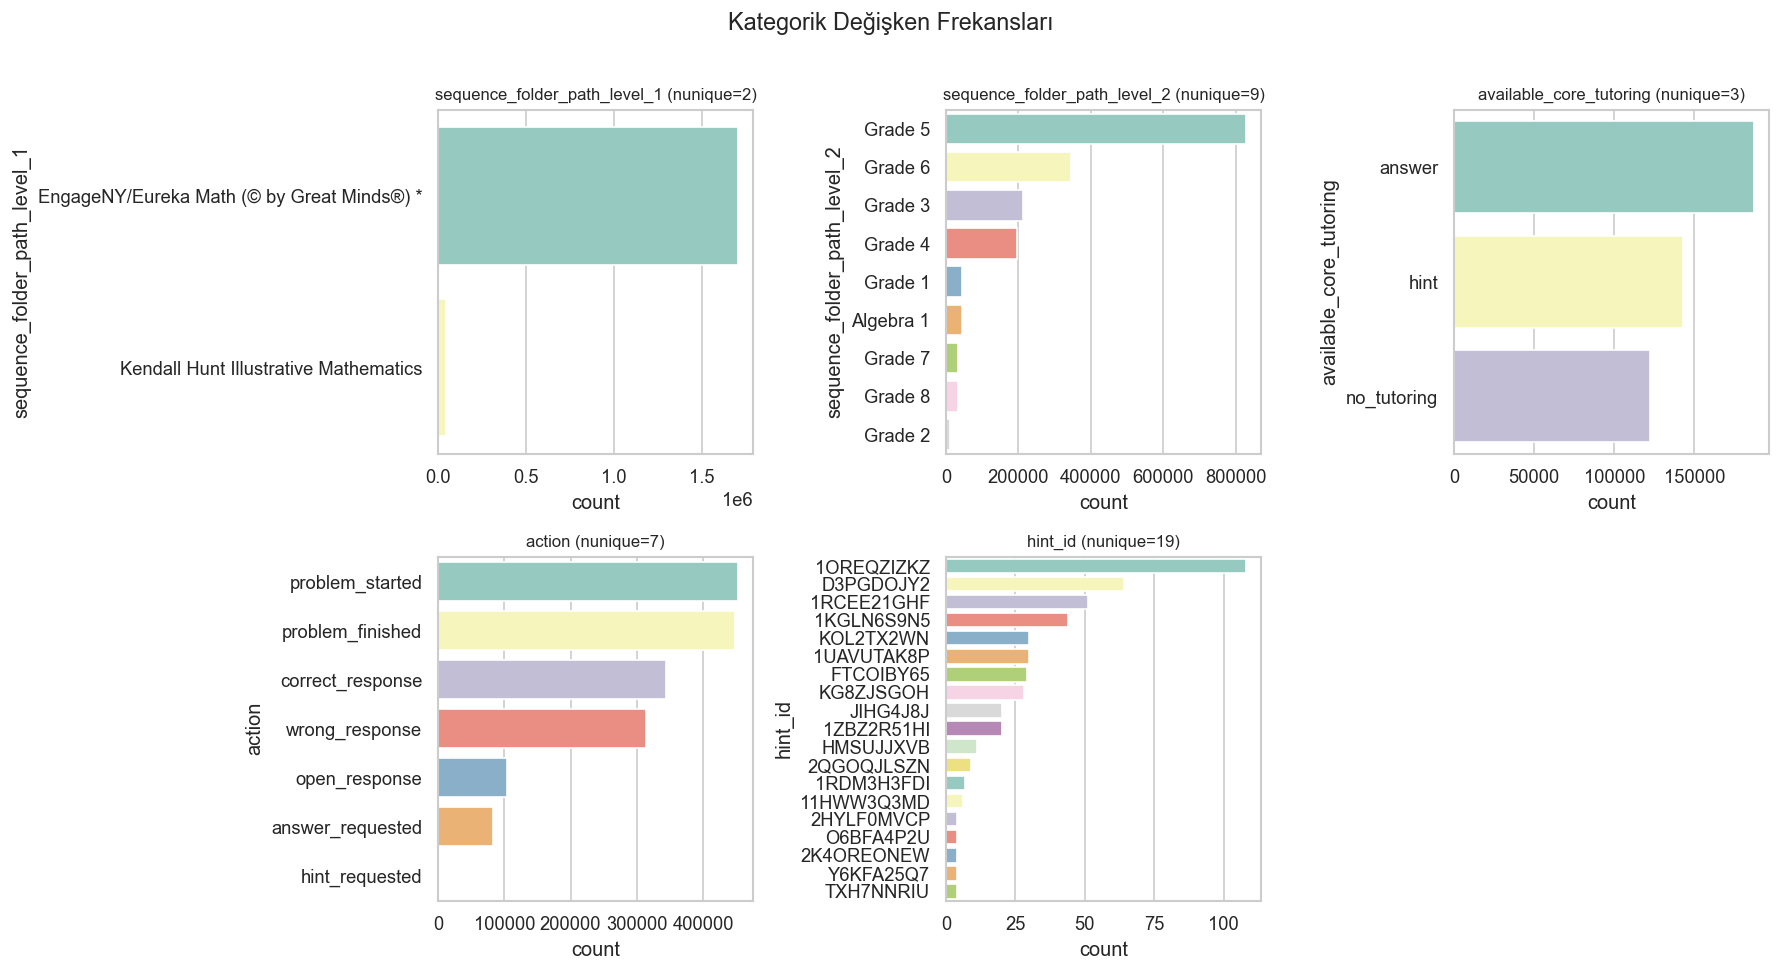

Yüksek Kardinaliteli Sütunlar (grafik gösterilmedi):
   assignment_log_id: 15,468 benzersiz değer
   problem_id: 7,062 benzersiz değer
   student_id: 1,499 benzersiz değer
   sequence_id: 670 benzersiz değer
   sequence_name: 670 benzersiz değer
   sequence_problem_ids: 670 benzersiz değer
   sequence_folder_path_level_4: 236 benzersiz değer
   class_id: 127 benzersiz değer
   teacher_id: 95 benzersiz değer
   sequence_folder_path_level_3: 39 benzersiz değer


In [14]:
# Kardinalitesi düşük (görselleştirilebilir) kategorik sütunlar
cat_to_plot = [c for c in categorical_cols_raw if df[c].nunique() <= 20][:6]

if cat_to_plot:
    n = len(cat_to_plot)
    rows = (n + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(15, rows*4))
    axes = axes.flatten() if n > 1 else [axes]
    for i, col in enumerate(cat_to_plot):
        order = df[col].value_counts().index
        sns.countplot(data=df, y=col, ax=axes[i], order=order, palette='Set3')
        axes[i].set_title(f'{col} (nunique={df[col].nunique()})', fontsize=10)
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Kategorik Değişken Frekansları', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

# Yüksek kardinaliteli sütunları raporla
high_card = [(c, df[c].nunique()) for c in categorical_cols_raw if df[c].nunique() > 20]
if high_card:
    print('Yüksek Kardinaliteli Sütunlar (grafik gösterilmedi):')
    for col, n in sorted(high_card, key=lambda x: -x[1]):
        print(f'   {col}: {n:,} benzersiz değer')

## 1.12 Ham Veri Korelasyon Analizi

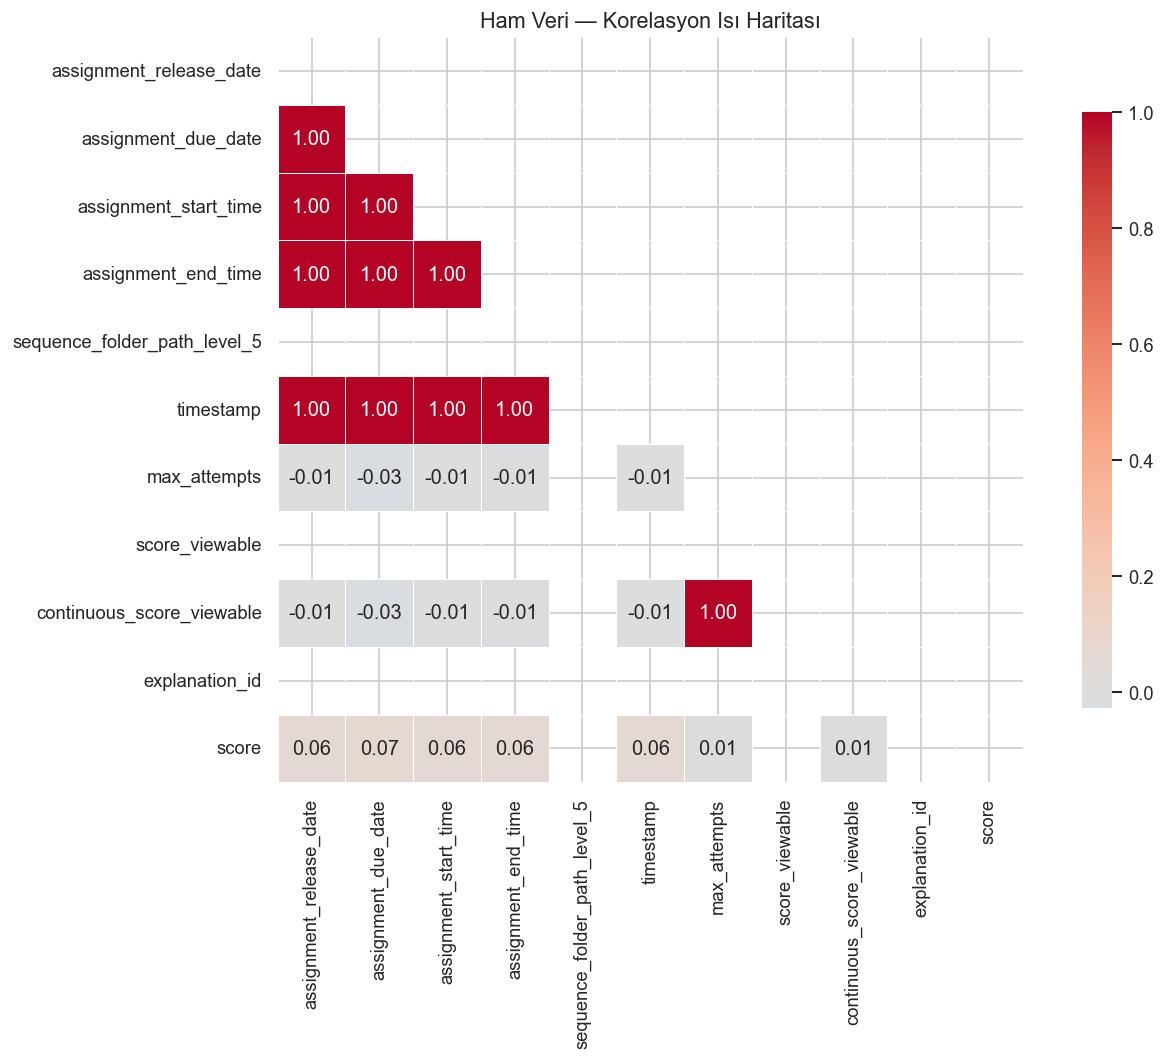

YÜKSEK KORELASYONLU ÇİFTLER (|r| > 0.7):


,Değişken 1,Değişken 2,Korelasyon
10,max_attempts,continuous_score_viewable,1.0000
1,assignment_release_date,assignment_start_time,0.9995
9,assignment_end_time,timestamp,0.9989
0,assignment_release_date,assignment_due_date,0.9982
4,assignment_due_date,assignment_start_time,0.9982
8,assignment_start_time,timestamp,0.9982
3,assignment_release_date,timestamp,0.9975
7,assignment_start_time,assignment_end_time,0.9972
6,assignment_due_date,timestamp,0.9970
2,assignment_release_date,assignment_end_time,0.9965


Timestamp sütunları birbirine r≈1 çünkü Unix formatında — dönüştürülecek.


In [15]:
corr_raw = df[numeric_cols_raw].corr()
mask = np.triu(np.ones_like(corr_raw, dtype=bool))

plt.figure(figsize=(12, 9))
sns.heatmap(corr_raw, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Ham Veri — Korelasyon Isı Haritası', fontsize=13)
plt.tight_layout()
plt.show()

# Yüksek korelasyonlu çiftler
high_corr = []
for i in range(len(corr_raw.columns)):
    for j in range(i+1, len(corr_raw.columns)):
        val = corr_raw.iloc[i, j]
        if abs(val) > 0.7 and not np.isnan(val):
            high_corr.append({'Değişken 1': corr_raw.columns[i],
                               'Değişken 2': corr_raw.columns[j],
                               'Korelasyon': round(val, 4)})
if high_corr:
    print('YÜKSEK KORELASYONLU ÇİFTLER (|r| > 0.7):')
    display(pd.DataFrame(high_corr).sort_values('Korelasyon', key=abs, ascending=False))
    print('Timestamp sütunları birbirine r≈1 çünkü Unix formatında — dönüştürülecek.')
else:
    print('Eşiği aşan yüksek korelasyon çifti bulunamadı.')

## 1.13 Normallik Testi (Çarpıklık & Basıklık)

In [16]:
normality_rows = []
for col in numeric_cols_raw:
    data = df[col].dropna()
    skew = data.skew()
    kurt = data.kurtosis()
    if len(data) <= 5000:
        stat, p = stats.shapiro(data)
    else:
        stat, p = stats.kstest(data, 'norm', args=(data.mean(), data.std()))
    normality_rows.append({
        'Sütun': col, 'Çarpıklık': round(skew,3), 'Basıklık': round(kurt,3),
        'Test İst.': round(stat,4), 'p-değeri': round(p,4),
        'Durum': 'Normal' if p > 0.05 else 'Normal Değil'
    })

norm_df = pd.DataFrame(normality_rows)
print('ÇARPIKLIK / BASIKLIK / NORMALLİK ANALİZİ — HAM VERİ')
display(norm_df)
print('Çarpıklık > |1| → Yüksek çarpıklık (dönüşüm önerilebilir)')
print('Basıklık > 3    → Ağır kuyruklı dağılım (leptokurtik)')

ÇARPIKLIK / BASIKLIK / NORMALLİK ANALİZİ — HAM VERİ


,Sütun,Çarpıklık,Basıklık,Test İst.,p-değeri,Durum
0,assignment_release_date,-2.706,8.047,0.2273,0.0,Normal Değil
1,assignment_due_date,-2.105,3.967,0.2237,0.0,Normal Değil
2,assignment_start_time,-2.714,8.099,0.2308,0.0,Normal Değil
3,assignment_end_time,-2.638,7.385,0.2239,0.0,Normal Değil
4,sequence_folder_path_level_5,NaN,NaN,NaN,NaN,Normal Değil
5,timestamp,-2.699,8.071,0.2215,0.0,Normal Değil
6,max_attempts,-1.272,-0.381,0.4769,0.0,Normal Değil
7,score_viewable,0.000,0.000,NaN,NaN,Normal Değil
8,continuous_score_viewable,-1.272,-0.381,0.4769,0.0,Normal Değil
9,explanation_id,NaN,NaN,NaN,NaN,Normal Değil


Çarpıklık > |1| → Yüksek çarpıklık (dönüşüm önerilebilir)
Basıklık > 3    → Ağır kuyruklı dağılım (leptokurtik)


## 1.14 Ham Veri EDA Özet Raporu

In [17]:
print('HAM VERİ EDA ÖZET RAPORU')
print(f'Boyut                    : {df.shape[0]:,} satır × {df.shape[1]} sütun')
print(f'Sayısal sütun            : {len(numeric_cols_raw)}')
print(f'Kategorik sütun          : {len(categorical_cols_raw)}')
print(f'Toplam eksik değer       : {df.isnull().sum().sum():,}')
print(f'Tekrar eden satır        : {df.duplicated().sum():,}')
print(f'Toplam aykırı değer      : {outlier_df["Aykırı Sayısı"].sum():,} (IQR)')
print(f'Normal dağılmayan sütun  : {(norm_df["Durum"]=="Normal Değil").sum()}')
print()
print('Tüm timestamp sütunları Unix formatında — anlamsız korelasyon oluşturuyor.')
print('%100 boş sütunlar mevcut — silinecek.')
print('Log verisi olduğundan önce aggregasyon yapılacak, sonra modelleme.')
print()
print('BÖLÜM 1 tamamlandı → BÖLÜM 2: Ön Temizlik')

HAM VERİ EDA ÖZET RAPORU
Boyut                    : 1,745,977 satır × 26 sütun
Sayısal sütun            : 11
Kategorik sütun          : 15
Toplam eksik değer       : 11,319,522
Tekrar eden satır        : 1,006,409
Toplam aykırı değer      : 643,431 (IQR)
Normal dağılmayan sütun  : 11

Tüm timestamp sütunları Unix formatında — anlamsız korelasyon oluşturuyor.
%100 boş sütunlar mevcut — silinecek.
Log verisi olduğundan önce aggregasyon yapılacak, sonra modelleme.

BÖLÜM 1 tamamlandı → BÖLÜM 2: Ön Temizlik


---
# BÖLÜM 2 — Ön Temizlik & Timestamp Dönüşümü
## 2.1 Gereksiz Sütunları Sil

In [18]:
df_clean = df.copy()

# %100 boş sütunları sileceğiz
fully_empty = [c for c in df_clean.columns if df_clean[c].isnull().mean() == 1.0]
df_clean.drop(columns=fully_empty, inplace=True)
print(f'Silinen %100 boş sütunlar ({len(fully_empty)}): {fully_empty}')

# hint_id → binary flag
if 'hint_id' in df_clean.columns:
    df_clean['used_hint'] = df_clean['hint_id'].notna().astype(int)
    df_clean.drop(columns=['hint_id'], inplace=True)
    print('✅ hint_id → used_hint (0/1 binary flag) olarak dönüştürüldü')

print(f'Temizlik sonrası: {df_clean.shape[0]:,} satır × {df_clean.shape[1]} sütun')

Silinen %100 boş sütunlar (2): ['sequence_folder_path_level_5', 'explanation_id']
✅ hint_id → used_hint (0/1 binary flag) olarak dönüştürüldü
Temizlik sonrası: 1,745,977 satır × 24 sütun


## 2.2 Unix Timestamp → Datetime Dönüşümü

In [19]:
time_cols = ['assignment_release_date', 'assignment_due_date',
             'assignment_start_time', 'assignment_end_time', 'timestamp']

for col in time_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], unit='s', errors='coerce')
        print(f'{col}: Unix → datetime dönüştürüldü')
        print(f'Aralık: {df_clean[col].min()} → {df_clean[col].max()}')

assignment_release_date: Unix → datetime dönüştürüldü
Aralık: 2019-02-25 19:20:39.786000013 → 2020-03-27 13:49:44.746999979
assignment_due_date: Unix → datetime dönüştürüldü
Aralık: 2019-02-25 19:22:00 → 2020-06-05 14:28:00
assignment_start_time: Unix → datetime dönüştürüldü
Aralık: 2019-02-25 19:20:57.473999977 → 2020-03-27 14:03:26.413000107
assignment_end_time: Unix → datetime dönüştürüldü
Aralık: 2019-02-26 17:06:46.306999922 → 2020-06-24 14:48:08.411999941
timestamp: Unix → datetime dönüştürüldü
Aralık: 2019-02-25 19:20:58.270999908 → 2020-06-24 14:48:08.365000010


## 2.3 Sadece Skorlu Satırları Tut

In [20]:
df_scored = df_clean[df_clean['score'].notna()].copy()

print('SKORLU SATIRLAR — ACTION DAĞILIMI')
print(df_scored['action'].value_counts())
print(f'\nToplam ham satır   : {len(df_clean):,}')
print(f'Skorlu satır sayısı: {len(df_scored):,} (%{len(df_scored)/len(df_clean)*100:.1f})')
print(f'\nSkorlu score dağılımı:')
print(df_scored['score'].value_counts().sort_index())
print(f'Ortalama score: {df_scored["score"].mean():.4f}')

SKORLU SATIRLAR — ACTION DAĞILIMI
action
problem_started     452443
problem_finished    448057
correct_response    344429
wrong_response      314085
open_response       103624
answer_requested     82862
hint_requested         477
Name: count, dtype: int64

Toplam ham satır   : 1,745,977
Skorlu satır sayısı: 1,745,977 (%100.0)

Skorlu score dağılımı:
score
0     725734
1    1020243
Name: count, dtype: int64
Ortalama score: 0.5843


---
# BÖLÜM 3 — Feature Engineering
## 3.1 Öğrenci Bazında Aggregasyon

In [21]:
print('Öğrenci bazında özellikler hesaplanıyor...')

student_df = df_scored.groupby('student_id').agg(

    # ── TEMEL BAŞARI ───────────────────────────────────────
    avg_score           = ('score', 'mean'),
    total_attempts      = ('score', 'count'),
    correct_count       = ('score', 'sum'),
    score_std           = ('score', 'std'),

    # ── PROBLEM ÇEŞİTLİLİĞİ ───────────────────────────────
    unique_problems     = ('problem_id',          'nunique'),
    unique_sequences    = ('sequence_id',         'nunique'),
    unique_assignments  = ('assignment_log_id',   'nunique'),
    unique_classes      = ('class_id',            'nunique'),

    # ── YARDIM KULLANIMI ──────────────────────────────────
    hint_used_count     = ('used_hint', 'sum'),

    # ── ZAMAN ─────────────────────────────────────────────
    first_activity      = ('timestamp', 'min'),
    last_activity       = ('timestamp', 'max'),

    # ── DENEME HAKKI ──────────────────────────────────────
    avg_max_attempts    = ('max_attempts', 'mean'),

).reset_index()

# ── Türetilmiş Özellikler ────────────────────────────────
student_df['accuracy_rate']     = student_df['correct_count'] / student_df['total_attempts']
student_df['hint_rate']         = student_df['hint_used_count'] / student_df['total_attempts']
student_df['problems_per_seq']  = (student_df['unique_problems']
                                   / student_df['unique_sequences'].replace(0, 1))
student_df['active_days']       = (
    (student_df['last_activity'] - student_df['first_activity'])
    .dt.days.clip(lower=0)
)
student_df['problems_per_day']  = (
    student_df['total_attempts'] / student_df['active_days'].replace(0, 1)
)

student_df.drop(columns=['first_activity', 'last_activity'], inplace=True)

print(f'Öğrenci tablosu oluşturuldu.')
print(f'Öğrenci sayısı  : {len(student_df):,}')
print(f'Feature sayısı  : {student_df.shape[1] - 2} (student_id ve avg_score hariç)')
student_df.head()

Öğrenci bazında özellikler hesaplanıyor...
Öğrenci tablosu oluşturuldu.
Öğrenci sayısı  : 1,499
Feature sayısı  : 14 (student_id ve avg_score hariç)


,student_id,avg_score,total_attempts,correct_count,score_std,unique_problems,unique_sequences,unique_assignments,unique_classes,hint_used_count,avg_max_attempts,accuracy_rate,hint_rate,problems_per_seq,active_days,problems_per_day
0,1017HMBYFU,0.703704,81,57,0.459468,9,1,1,1,0,1.222222,0.703704,0.0,9.000000,0,81.000000
1,103JBDNOJU,0.614516,3541,2176,0.486778,171,14,14,1,0,2.630332,0.614516,0.0,12.214286,82,43.182927
2,106K7M3I,0.595188,1413,841,0.491029,111,4,5,1,0,2.837838,0.595188,0.0,27.750000,3,471.000000
3,109KD4C6EF,0.509904,1565,798,0.500062,86,6,7,1,0,2.469027,0.509904,0.0,14.333333,19,82.368421
4,109STA9TZ0,0.732283,127,93,0.444523,15,2,2,1,0,2.302326,0.732283,0.0,7.500000,3,42.333333


## 3.2 Aggrege Veri — İstatistiksel Özet

In [22]:
feature_cols_agg = [c for c in student_df.columns
                    if c not in ['student_id', 'avg_score']]

print('AGGREGE VERİ — İSTATİSTİKSEL ÖZET')
student_df[feature_cols_agg].describe().T.style.background_gradient(cmap='Blues')

AGGREGE VERİ — İSTATİSTİKSEL ÖZET


,count,mean,std,min,25%,50%,75%,max
total_attempts,1499.000000,1164.761174,1769.802697,1.000000,176.000000,610.000000,1436.000000,16986.000000
correct_count,1499.000000,680.615744,991.653848,0.000000,99.500000,382.000000,860.000000,9211.000000
score_std,1467.000000,0.461999,0.078367,0.000000,0.458892,0.487654,0.497865,0.707107
unique_problems,1499.000000,86.723149,132.422328,1.000000,13.000000,47.000000,103.000000,1223.000000
unique_sequences,1499.000000,10.002668,16.385134,1.000000,2.000000,4.000000,11.000000,105.000000
unique_assignments,1499.000000,10.318879,16.516884,1.000000,2.000000,5.000000,11.000000,106.000000
unique_classes,1499.000000,1.048699,0.215310,1.000000,1.000000,1.000000,1.000000,2.000000
hint_used_count,1499.000000,0.318212,2.487782,0.000000,0.000000,0.000000,0.000000,43.000000
avg_max_attempts,1499.000000,2.592119,0.354184,1.000000,2.427631,2.607143,2.876697,3.000000
accuracy_rate,1499.000000,0.594032,0.168104,0.000000,0.512502,0.599106,0.689327,1.000000


In [23]:
# Eksik değer kontrolü (aggrege veri)
missing_agg = student_df[feature_cols_agg].isnull().sum()
missing_agg = missing_agg[missing_agg > 0]
if len(missing_agg) > 0:
    print('Aggrege verideki eksik değerler:')
    print(missing_agg)
    student_df['score_std'].fillna(0, inplace=True)    
    student_df['avg_max_attempts'].fillna(
        student_df['avg_max_attempts'].median(), inplace=True)
    print('Eksik değerler dolduruldu.')
else:
    print('Aggrege veride eksik değer yok.')

Aggrege verideki eksik değerler:
score_std    32
dtype: int64
Eksik değerler dolduruldu.


## 3.3 Aggrege Veri — Dağılım Grafikleri

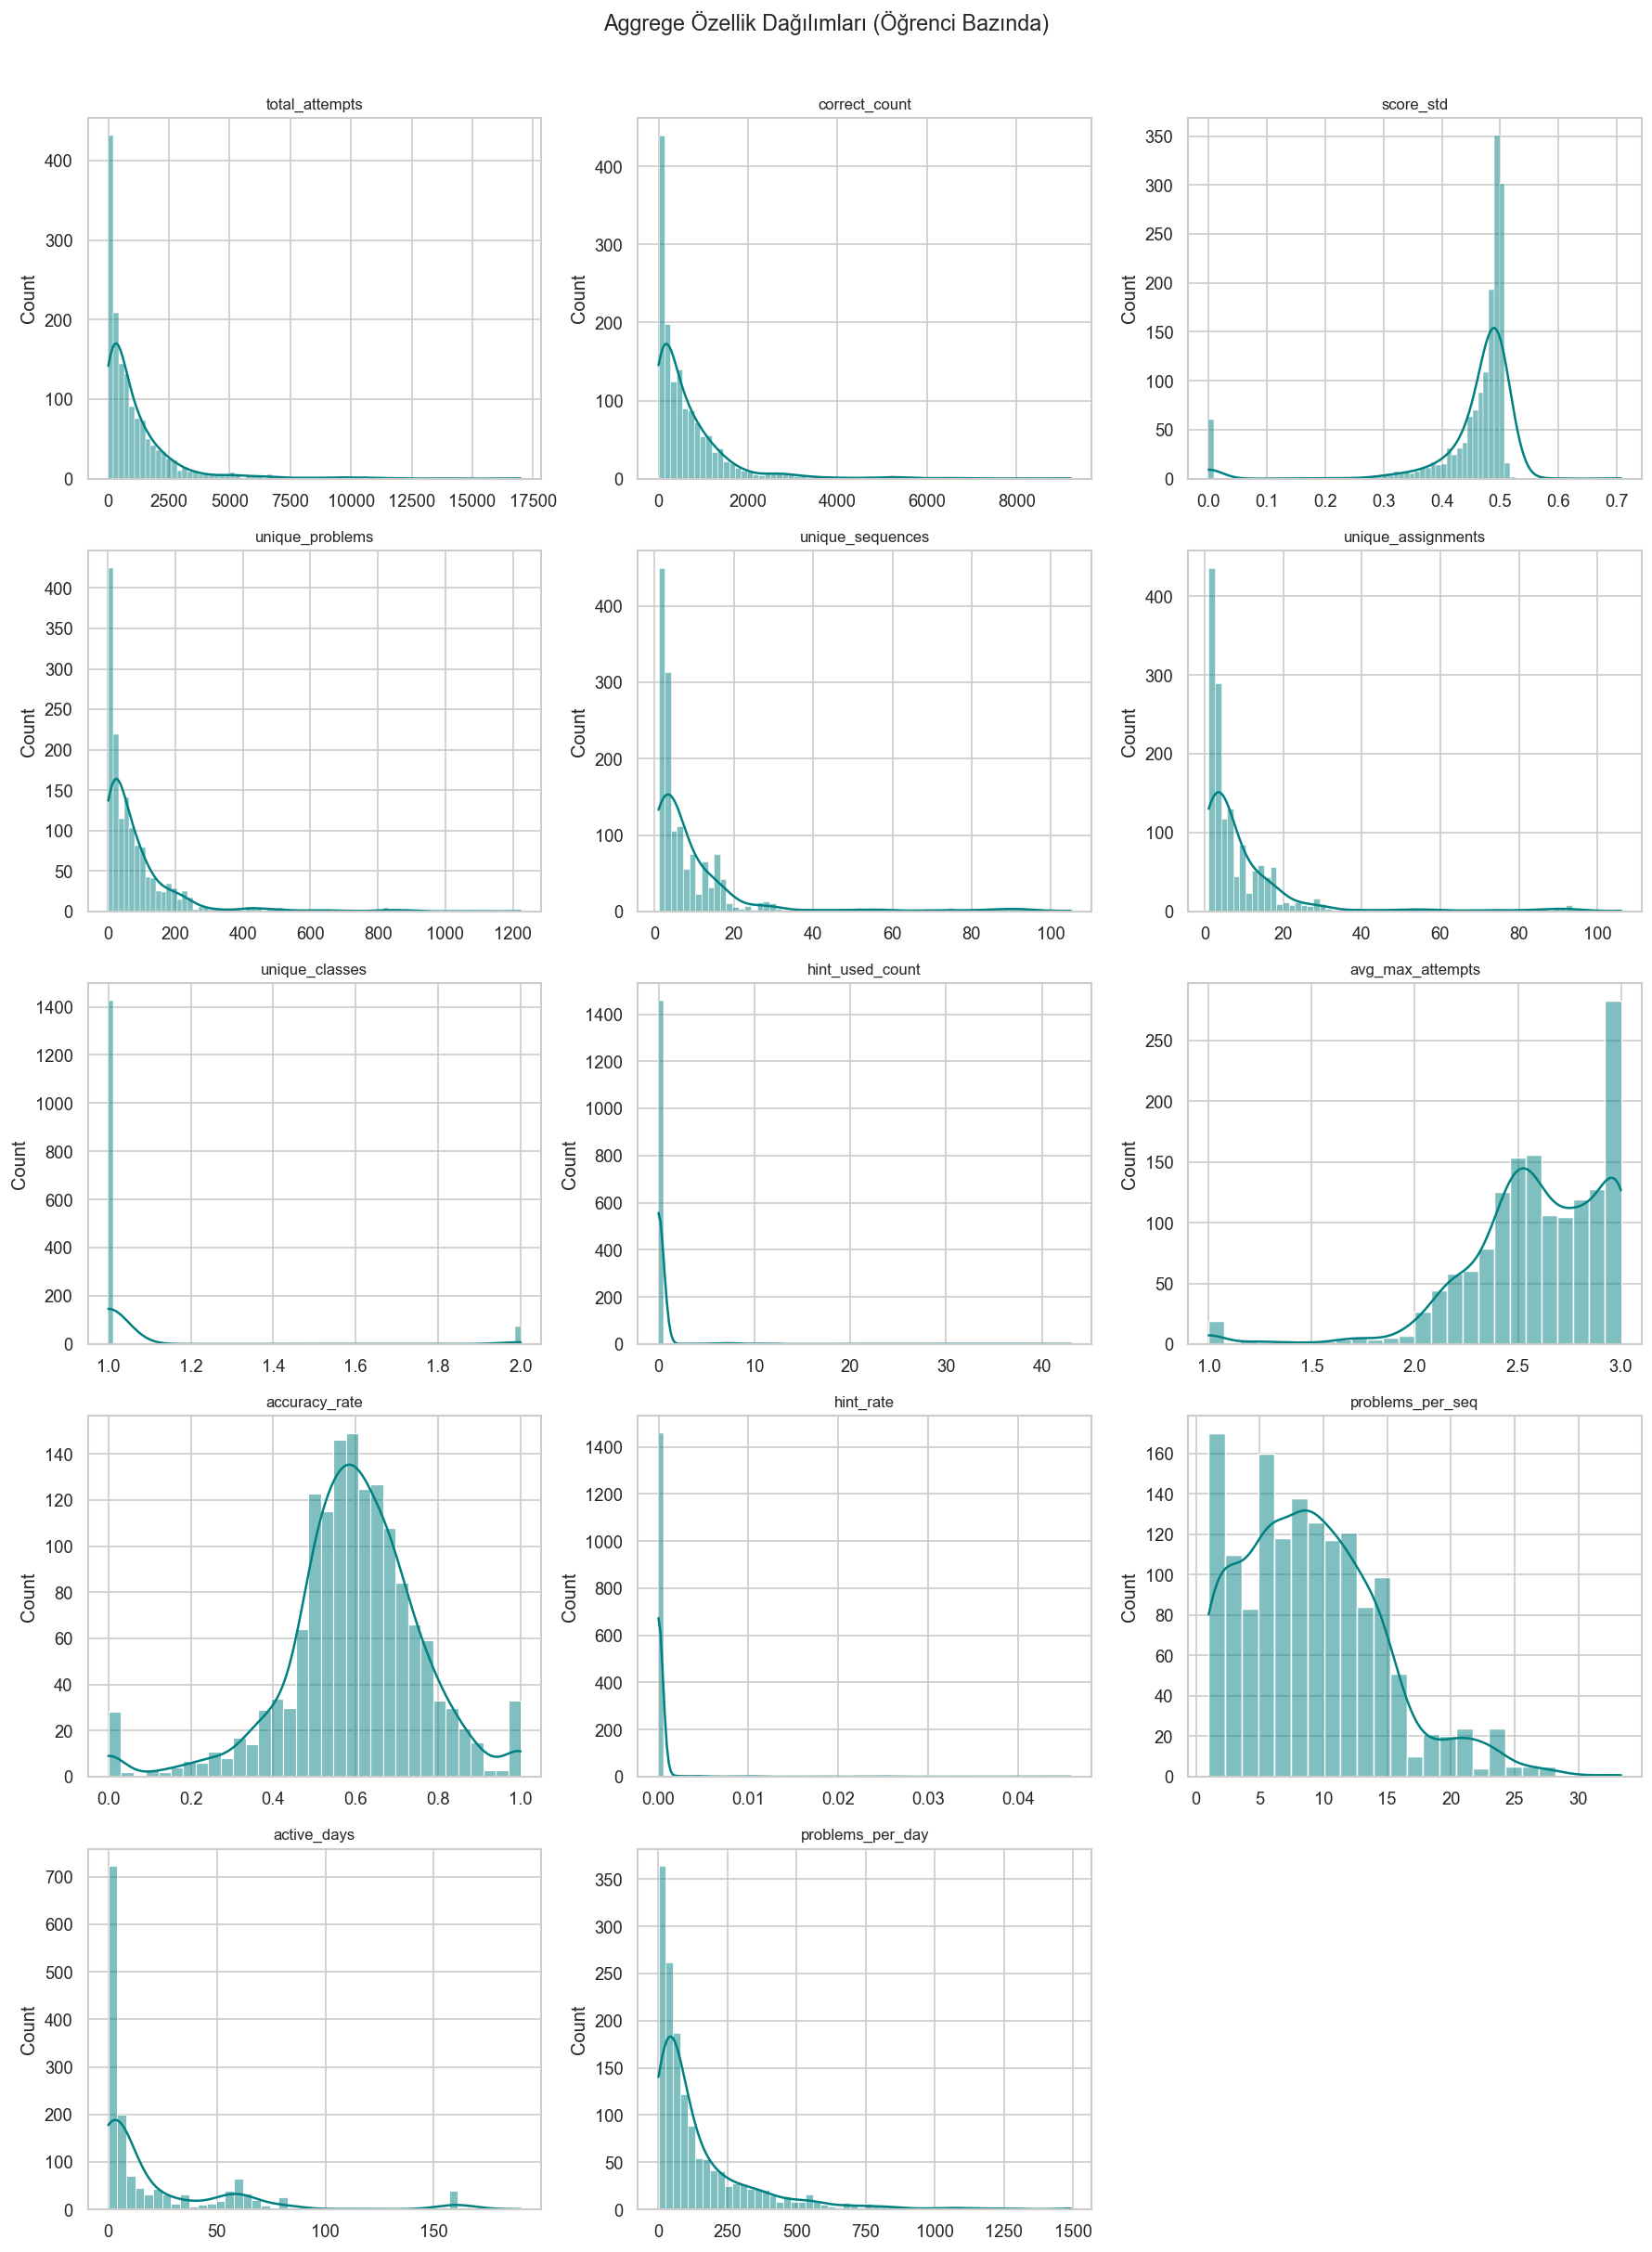

In [24]:
n = len(feature_cols_agg)
rows = (n + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(15, rows*4))
axes = axes.flatten() if n > 1 else [axes]

for i, col in enumerate(feature_cols_agg):
    sns.histplot(student_df[col].dropna(), kde=True, ax=axes[i], color='teal')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Aggrege Özellik Dağılımları (Öğrenci Bazında)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
# BÖLÜM 4 — Hedef Değişken Oluşturma
## 4.1 avg_score Dağılımı

AVG_SCORE DAĞILIMI (Öğrenci Bazında)
count    1499.0000
mean        0.5940
std         0.1681
min         0.0000
25%         0.5125
50%         0.5991
75%         0.6893
max         1.0000
Name: avg_score, dtype: float64

Quartile sınırları: Q1=0.513, Q2=0.599, Q3=0.689


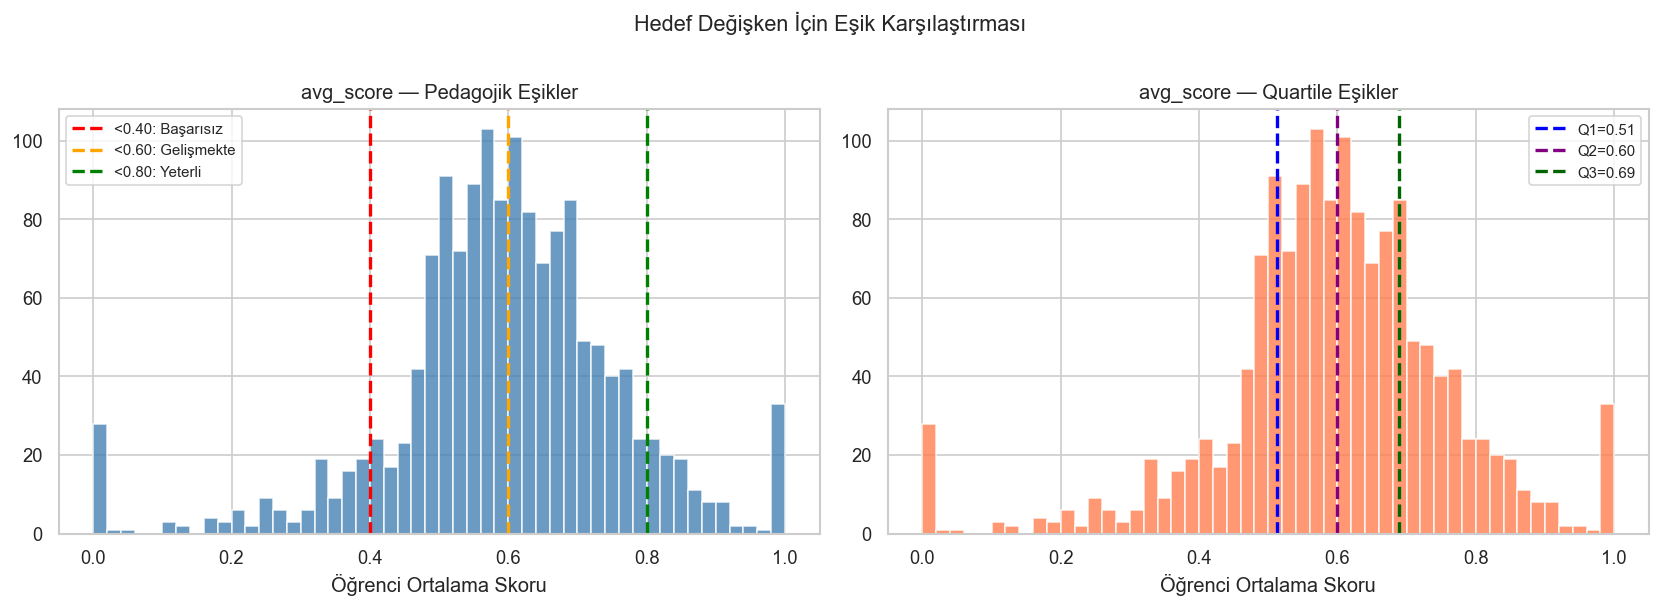

In [25]:
print('AVG_SCORE DAĞILIMI (Öğrenci Bazında)')
print(student_df['avg_score'].describe().round(4))

q_vals = student_df['avg_score'].quantile([0.25, 0.50, 0.75])
print(f'\nQuartile sınırları: Q1={q_vals[0.25]:.3f}, Q2={q_vals[0.50]:.3f}, Q3={q_vals[0.75]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pedagojik eşikler
axes[0].hist(student_df['avg_score'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
for thresh, color, label in [(0.40,'red','<0.40: Başarısız'),
                               (0.60,'orange','<0.60: Gelişmekte'),
                               (0.80,'green','<0.80: Yeterli')]:
    axes[0].axvline(thresh, color=color, linestyle='--', linewidth=2, label=label)
axes[0].set_title('avg_score — Pedagojik Eşikler', fontsize=12)
axes[0].set_xlabel('Öğrenci Ortalama Skoru')
axes[0].legend(fontsize=9)

# Quartile eşikler
axes[1].hist(student_df['avg_score'], bins=50, color='coral', edgecolor='white', alpha=0.8)
for q, color, label in [(0.25,'blue', f'Q1={q_vals[0.25]:.2f}'),
                         (0.50,'purple', f'Q2={q_vals[0.50]:.2f}'),
                         (0.75,'darkgreen', f'Q3={q_vals[0.75]:.2f}')]:
    axes[1].axvline(q_vals[q], color=color, linestyle='--', linewidth=2, label=label)
axes[1].set_title('avg_score — Quartile Eşikler', fontsize=12)
axes[1].set_xlabel('Öğrenci Ortalama Skoru')
axes[1].legend(fontsize=9)

plt.suptitle('Hedef Değişken İçin Eşik Karşılaştırması', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4.2 Üç Strateji ile Hedef Değişken Oluştur

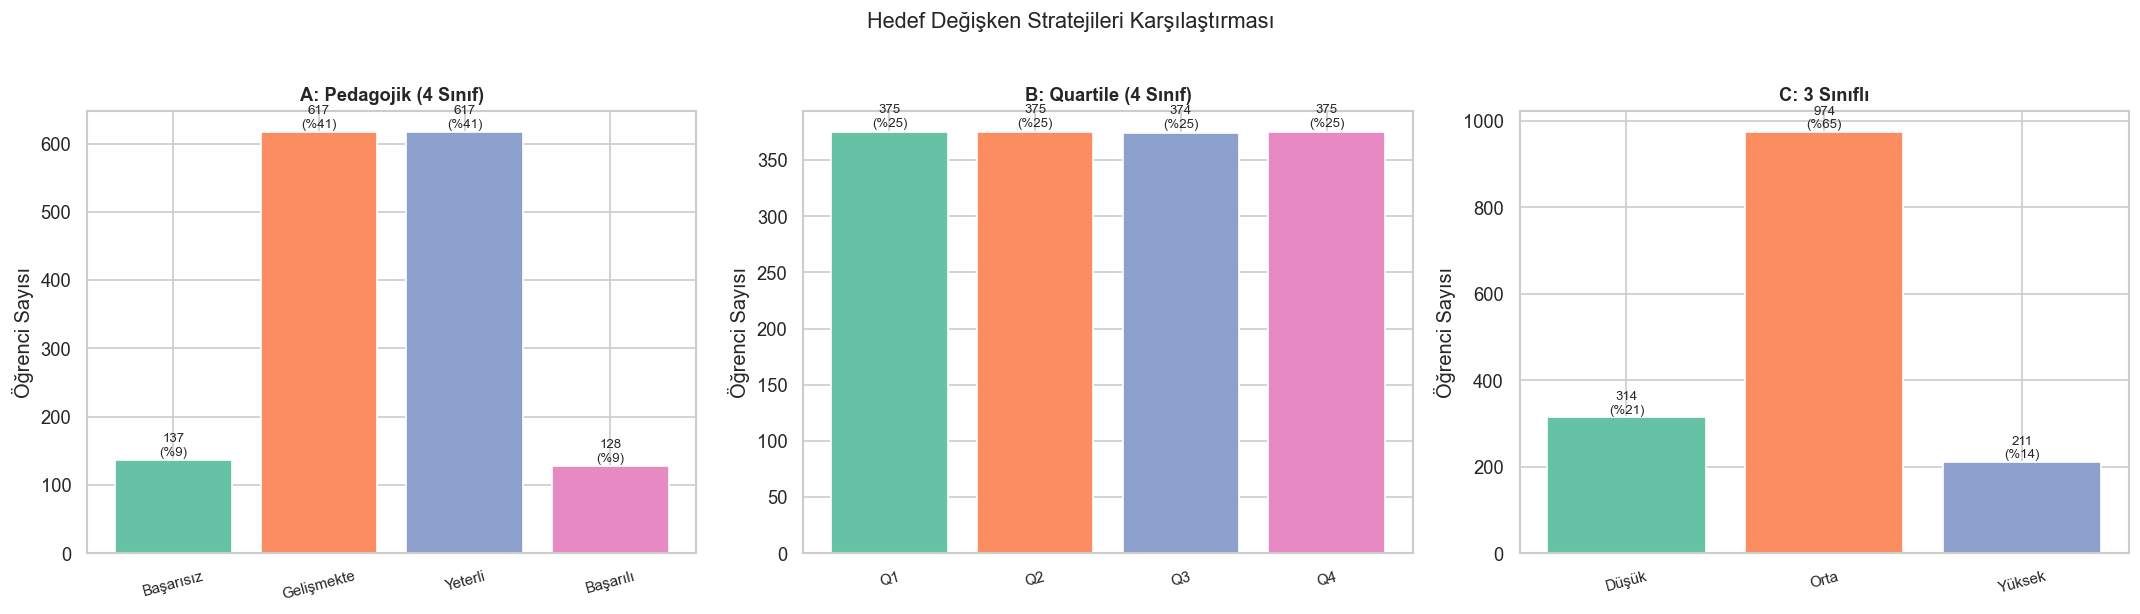

DENGESİZLİK KARŞILAŞTIRMASI
A: Pedagojik (4 Sınıf): dengesizlik oranı = 4.8x
B: Quartile (4 Sınıf): dengesizlik oranı = 1.0x
C: 3 Sınıflı: dengesizlik oranı = 4.6x


In [26]:
# STRATEJİ A: Pedagojik eşikler 
def pedagogical_label(s):
    if s < 0.40:   return 0  # Başarısız
    elif s < 0.60: return 1  # Gelişmekte
    elif s < 0.80: return 2  # Yeterli
    else:          return 3  # Başarılı

student_df['target_pedagogical'] = student_df['avg_score'].apply(pedagogical_label)

# STRATEJİ B: Quartile bazlı 
student_df['target_quartile'] = pd.qcut(
    student_df['avg_score'], q=4,
    labels=[0, 1, 2, 3], duplicates='drop'
).astype(int)

# STRATEJİ C: 3 Sınıf 
def three_class_label(s):
    if s < 0.50:   return 0  # Düşük
    elif s < 0.75: return 1  # Orta
    else:          return 2  # Yüksek

student_df['target_3class'] = student_df['avg_score'].apply(three_class_label)

# ── Karşılaştırma Grafikleri ─────────────────────────────
targets = [
    ('target_pedagogical', 'A: Pedagojik (4 Sınıf)', ['Başarısız','Gelişmekte','Yeterli','Başarılı']),
    ('target_quartile',    'B: Quartile (4 Sınıf)',  ['Q1','Q2','Q3','Q4']),
    ('target_3class',      'C: 3 Sınıflı',           ['Düşük','Orta','Yüksek']),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, title, labels) in zip(axes, targets):
    vc = student_df[col].value_counts().sort_index()
    bars = ax.bar(range(len(vc)), vc.values,
                  color=sns.color_palette('Set2', len(vc)))
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(labels[:len(vc)], rotation=15, fontsize=9)
    ax.set_ylabel('Öğrenci Sayısı')
    for bar, val in zip(bars, vc.values):
        pct = val/len(student_df)*100
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                f'{val:,}\n(%{pct:.0f})', ha='center', va='bottom', fontsize=8)

plt.suptitle('Hedef Değişken Stratejileri Karşılaştırması', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Dengesizlik tablosu
print('DENGESİZLİK KARŞILAŞTIRMASI')
for col, title, labels in targets:
    vc = student_df[col].value_counts().sort_index()
    imb = vc.max() / vc.min()
    print(f'{title}: dengesizlik oranı = {imb:.1f}x')

## 4.3 Hedef Değişkeni Seç
> **Not:** Sonuçlara göre `CHOSEN_TARGET` değişkenini düzenle.

In [27]:
# 'target_pedagogical'  → A: Pedagojik 4 sınıf 
# 'target_quartile'     → B: Quartile 4 sınıf 
# 'target_3class'       → C: 3 sınıf         
CHOSEN_TARGET = 'target_pedagogical'

drop_from_X = ['student_id', 'avg_score',
               'target_pedagogical', 'target_quartile', 'target_3class']

X = student_df.drop(columns=drop_from_X).copy()
y = student_df[CHOSEN_TARGET].copy()

print(f'SEÇİLEN HEDEF: {CHOSEN_TARGET}')
print(f'X boyutu : {X.shape}')
print(f'y boyutu : {y.shape}')
print(f'\nFeature listesi:')
for i, c in enumerate(X.columns, 1):
    print(f'  {i:>2}. {c}')

label_names = {0:'Başarısız', 1:'Gelişmekte', 2:'Yeterli', 3:'Başarılı'}
print(f'\nSınıf dağılımı:')
for cls, cnt in y.value_counts().sort_index().items():
    lbl = label_names.get(cls, cls)
    print(f'  Sınıf {cls} ({lbl}): {cnt:,} öğrenci (%{cnt/len(y)*100:.1f})')

SEÇİLEN HEDEF: target_pedagogical
X boyutu : (1499, 14)
y boyutu : (1499,)

Feature listesi:
   1. total_attempts
   2. correct_count
   3. score_std
   4. unique_problems
   5. unique_sequences
   6. unique_assignments
   7. unique_classes
   8. hint_used_count
   9. avg_max_attempts
  10. accuracy_rate
  11. hint_rate
  12. problems_per_seq
  13. active_days
  14. problems_per_day

Sınıf dağılımı:
  Sınıf 0 (Başarısız): 137 öğrenci (%9.1)
  Sınıf 1 (Gelişmekte): 617 öğrenci (%41.2)
  Sınıf 2 (Yeterli): 617 öğrenci (%41.2)
  Sınıf 3 (Başarılı): 128 öğrenci (%8.5)


---
# BÖLÜM 5 — Feature Analizi (Aggrege Veri)
## 5.1 Feature Korelasyon Matrisi

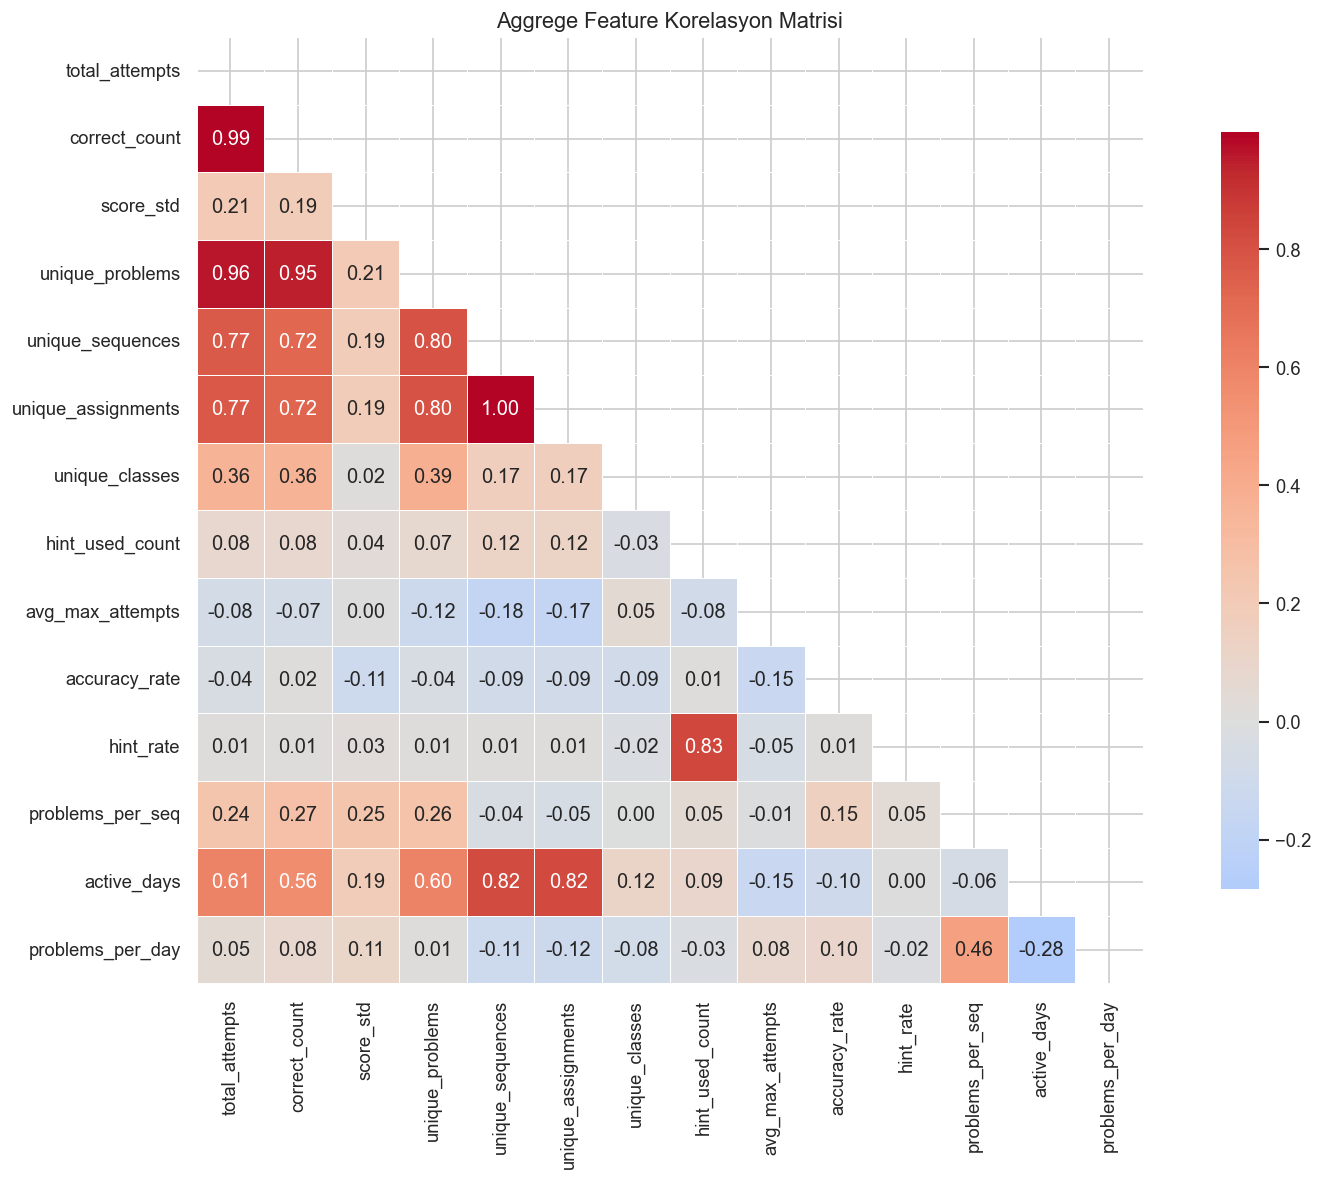

Yüksek Korelasyonlu Feature Çiftleri (|r| > 0.8):


,Değişken 1,Değişken 2,Korelasyon
3,unique_sequences,unique_assignments,0.9984
0,total_attempts,correct_count,0.9910
1,total_attempts,unique_problems,0.9601
2,correct_count,unique_problems,0.9455
6,hint_used_count,hint_rate,0.8340
5,unique_assignments,active_days,0.8233
4,unique_sequences,active_days,0.8187


Bu çiftlerden biri feature selection aşamasında çıkarılabilir.


In [28]:
corr_agg = X.corr()
mask_agg = np.triu(np.ones_like(corr_agg, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(corr_agg, mask=mask_agg, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Aggrege Feature Korelasyon Matrisi', fontsize=13)
plt.tight_layout()
plt.show()

# Yüksek korelasyonlu feature çiftleri
high_corr_feat = []
for i in range(len(corr_agg.columns)):
    for j in range(i+1, len(corr_agg.columns)):
        val = corr_agg.iloc[i, j]
        if abs(val) > 0.8 and not np.isnan(val):
            high_corr_feat.append({'Değişken 1': corr_agg.columns[i],
                                    'Değişken 2': corr_agg.columns[j],
                                    'Korelasyon': round(val,4)})
if high_corr_feat:
    print('Yüksek Korelasyonlu Feature Çiftleri (|r| > 0.8):')
    display(pd.DataFrame(high_corr_feat).sort_values('Korelasyon', key=abs, ascending=False))
    print('Bu çiftlerden biri feature selection aşamasında çıkarılabilir.')
else:
    print('Yüksek korelasyonlu feature çifti yok.')

## 5.2 Feature Önemi (Random Forest)

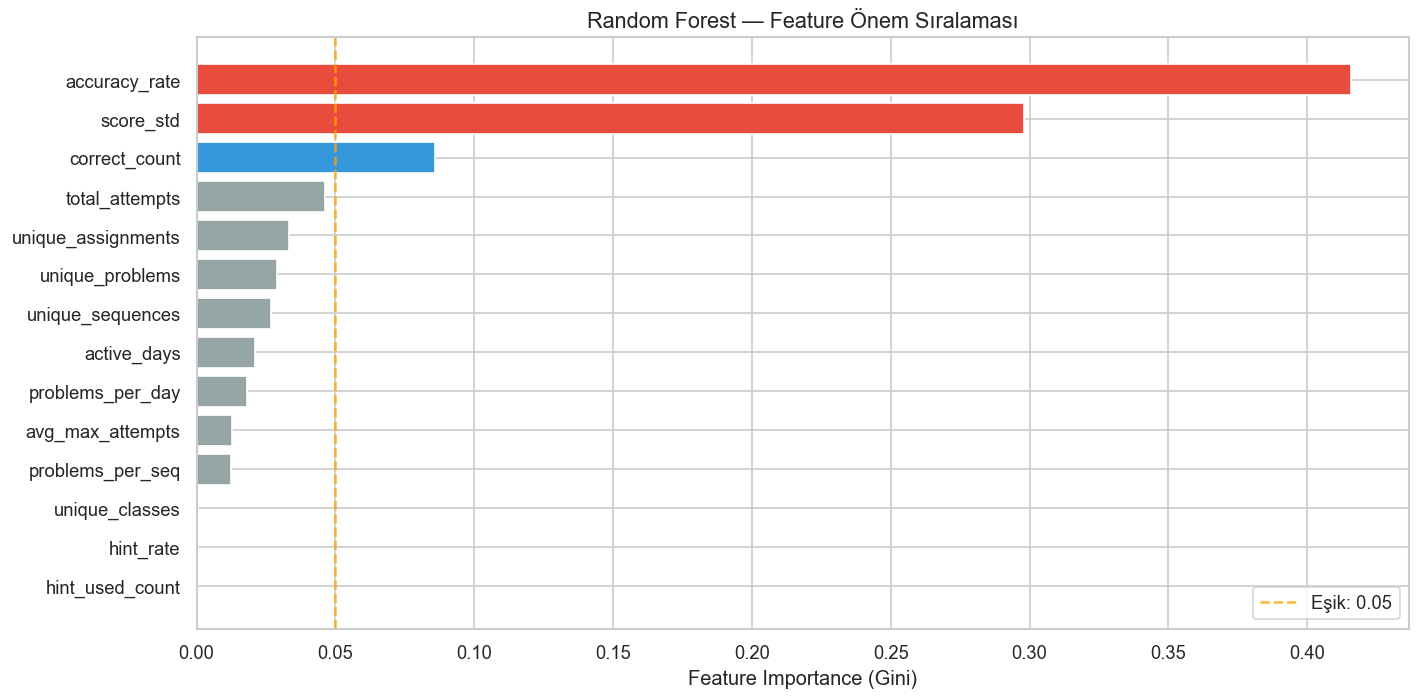

FEATURE ÖNEM SIRALAMA
🔴 accuracy_rate                  0.4158  ███████████████████████████████████████████████████████████████████████████████████
🔴 score_std                      0.2979  ███████████████████████████████████████████████████████████
🔵 correct_count                  0.0858  █████████████████
⚪ total_attempts                 0.0463  █████████
⚪ unique_assignments             0.0333  ██████
⚪ unique_problems                0.0291  █████
⚪ unique_sequences               0.0267  █████
⚪ active_days                    0.0210  ████
⚪ problems_per_day               0.0182  ███
⚪ avg_max_attempts               0.0129  ██
⚪ problems_per_seq               0.0123  ██
⚪ unique_classes                 0.0004  
⚪ hint_rate                      0.0004  
⚪ hint_used_count                0.0000  
Önem < 0.01 (çıkarılabilir): ['unique_classes', 'hint_rate', 'hint_used_count']


In [29]:
rf_quick = RandomForestClassifier(n_estimators=100, random_state=42,
                                   class_weight='balanced', n_jobs=-1)
rf_quick.fit(X, y)

fi = pd.Series(rf_quick.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors = ['#e74c3c' if v > 0.10 else '#3498db' if v > 0.05 else '#95a5a6'
          for v in fi.values]
plt.barh(fi.index[::-1], fi.values[::-1], color=colors[::-1])
plt.axvline(0.05, color='orange', linestyle='--', alpha=0.8, label='Eşik: 0.05')
plt.xlabel('Feature Importance (Gini)', fontsize=12)
plt.title('Random Forest — Feature Önem Sıralaması', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

print('FEATURE ÖNEM SIRALAMA')
for feat, imp in fi.items():
    bar = '█' * int(imp * 200)
    tag = '🔴' if imp > 0.10 else '🔵' if imp > 0.05 else '⚪'
    print(f'{tag} {feat:<30} {imp:.4f}  {bar}')

low_importance = fi[fi < 0.01].index.tolist()
if low_importance:
    print(f'Önem < 0.01 (çıkarılabilir): {low_importance}')

## 5.3 Feature vs Hedef Değişken (Boxplot)

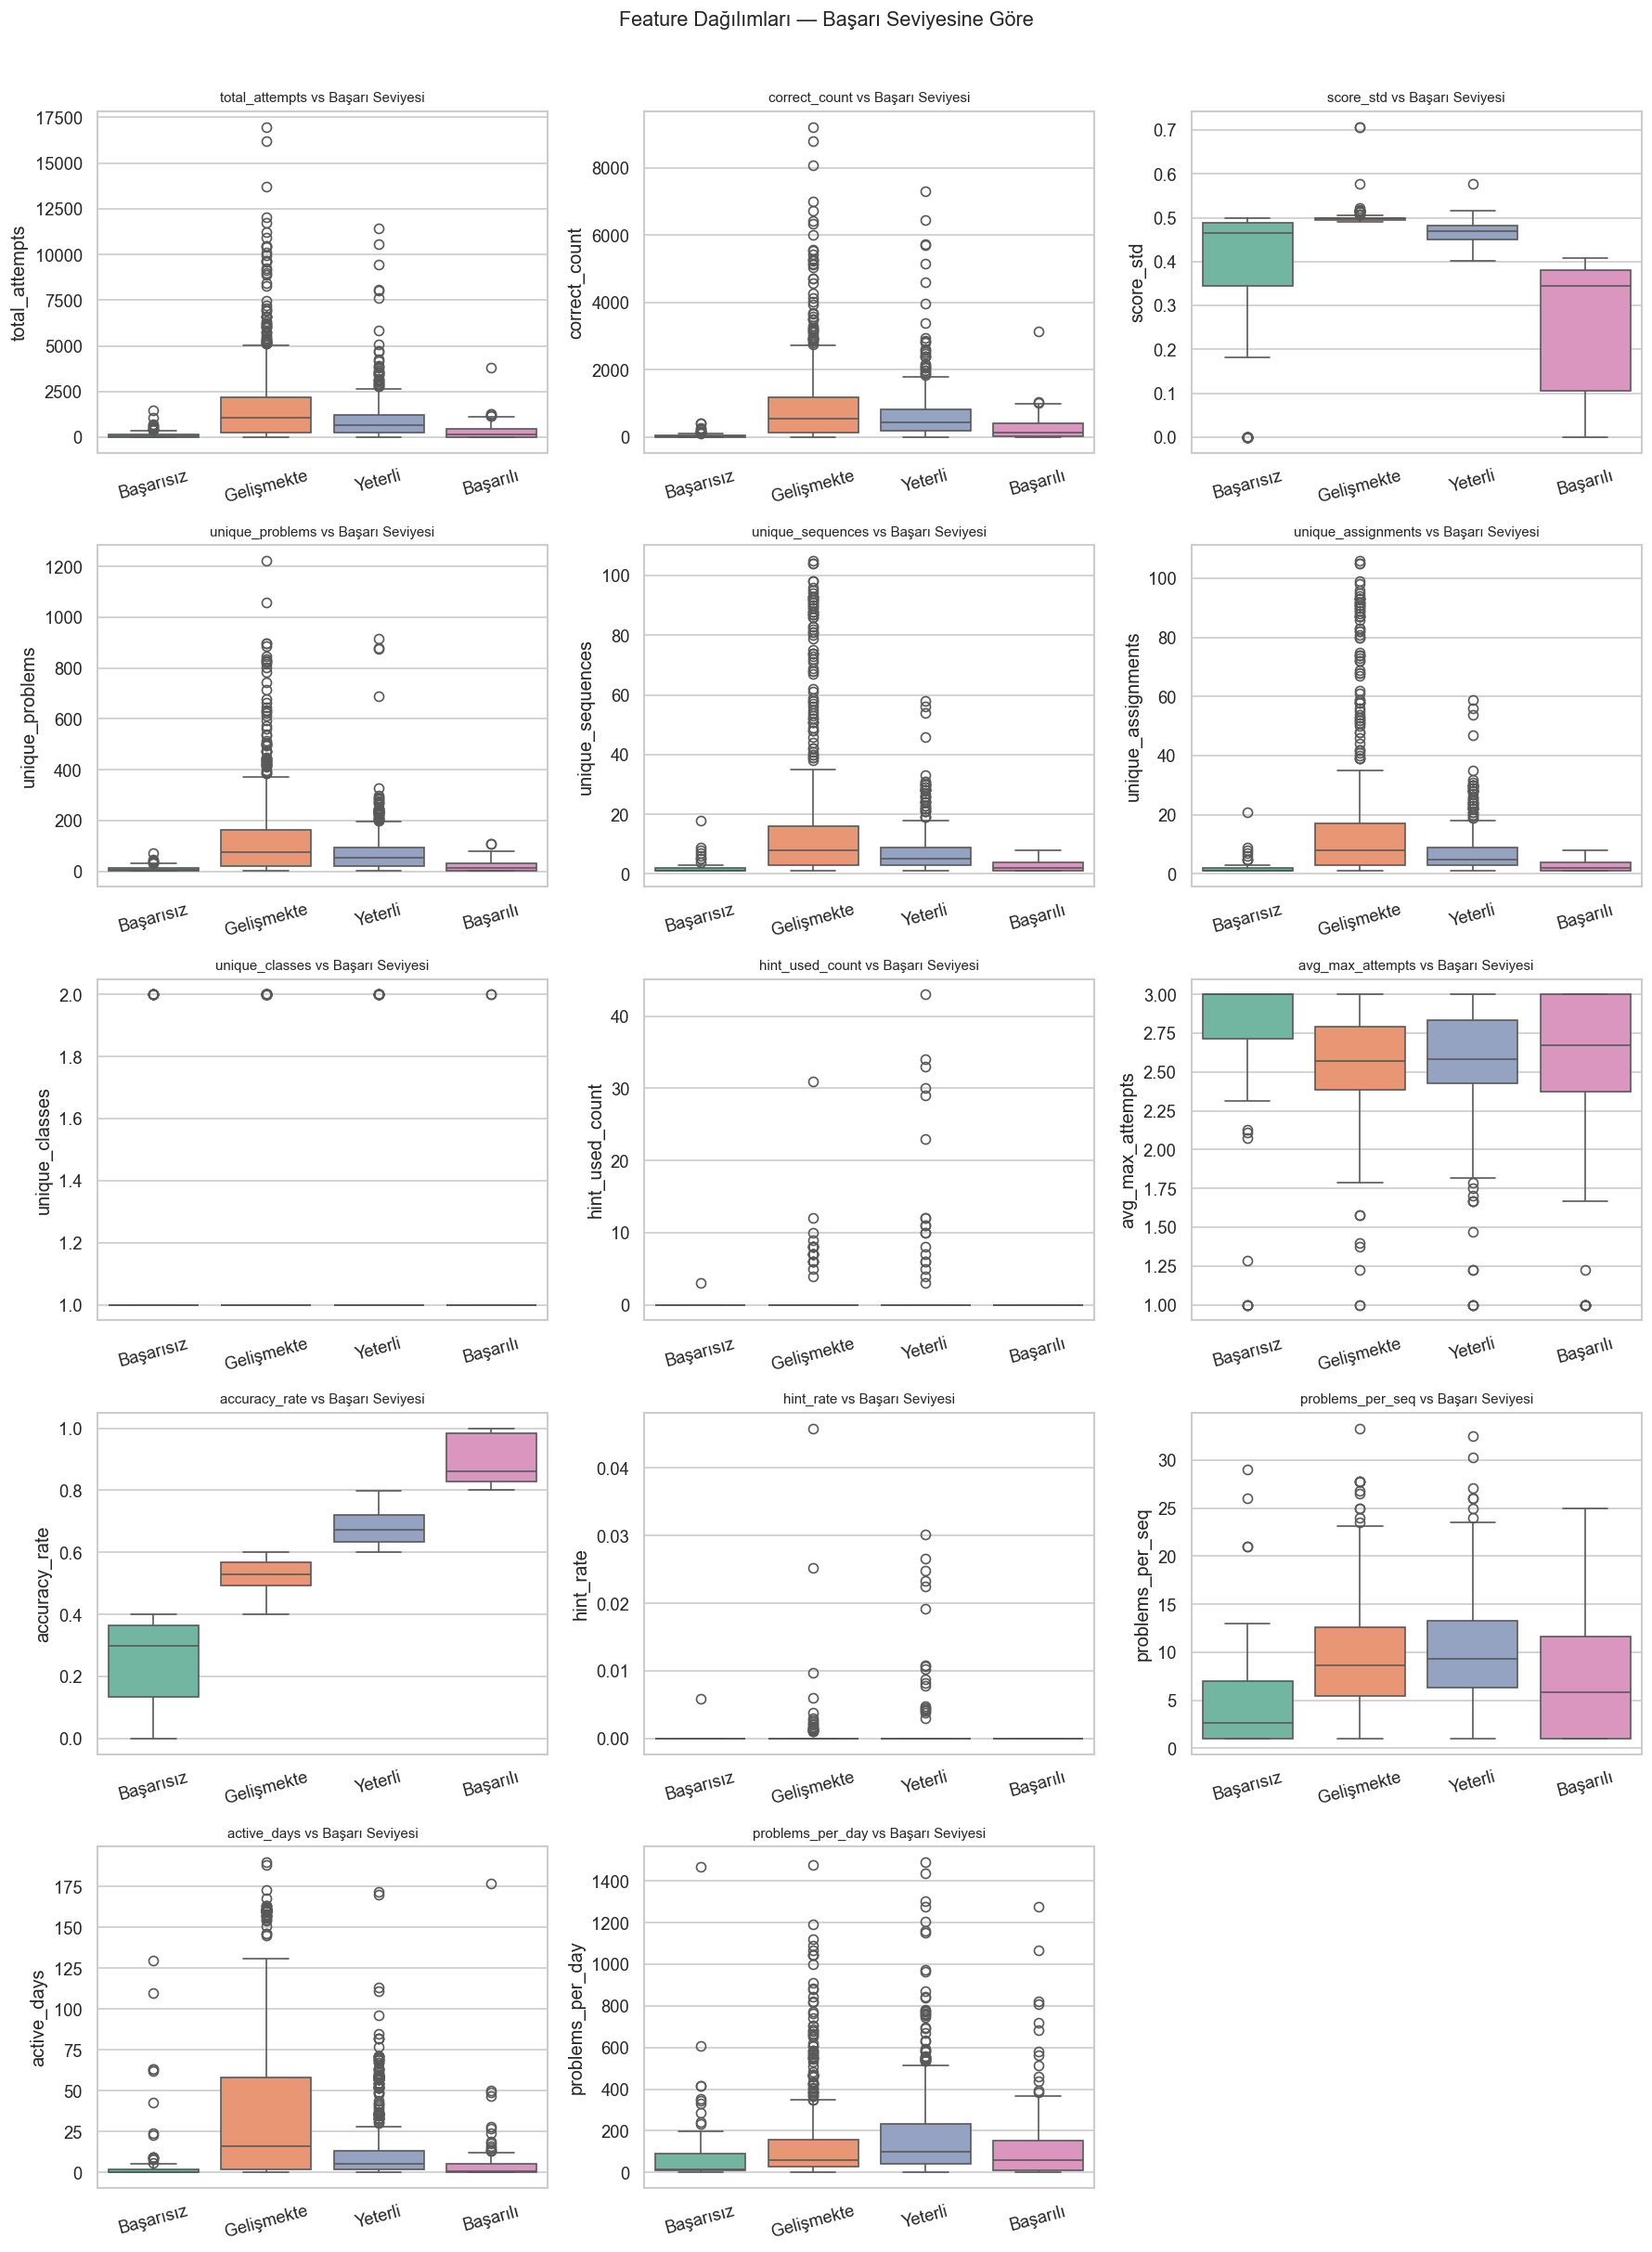

In [30]:
X_plot = X.copy()
X_plot['target'] = y.values

n = len(X.columns)
rows = (n + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(15, rows*4))
axes = axes.flatten() if n > 1 else [axes]

label_names = {0:'Başarısız', 1:'Gelişmekte', 2:'Yeterli', 3:'Başarılı'}
X_plot['target_label'] = X_plot['target'].map(label_names)

for i, col in enumerate(X.columns):
    order = [label_names[k] for k in sorted(y.unique())]
    sns.boxplot(data=X_plot, x='target_label', y=col,
                ax=axes[i], palette='Set2', order=order)
    axes[i].set_title(f'{col} vs Başarı Seviyesi', fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Dağılımları — Başarı Seviyesine Göre', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5.4 Veri Dengesizliği Kontrolü

In [31]:
vc = y.value_counts().sort_index()
imbalance_ratio = vc.max() / vc.min()

print('VERİ DENGESİZLİĞİ ANALİZİ')
print(vc)
print(f'Dengesizlik oranı (max/min): {imbalance_ratio:.2f}x')

if imbalance_ratio > 3:
    print('Ciddi dengesizlik — önerilen çözümler:')
    print('  • class_weight="balanced"')
    print('  • SMOTE')
    print('  • Stratified K-Fold ile train/test bölme')
elif imbalance_ratio > 1.5:
    print('Hafif dengesizlik — class_weight="balanced" yeterli.')
else:
    print('Veri dengeli — ek işlem gerekmez.')

VERİ DENGESİZLİĞİ ANALİZİ
target_pedagogical
0    137
1    617
2    617
3    128
Name: count, dtype: int64
Dengesizlik oranı (max/min): 4.82x
Ciddi dengesizlik — önerilen çözümler:
  • class_weight="balanced"
  • SMOTE
  • Stratified K-Fold ile train/test bölme


---
# BÖLÜM 6 — Çıktı: Modellemeye Hazır Veriyi Kaydet

In [32]:
final_df = X.copy()
final_df['target'] = y.values

final_df.to_csv('edm_2023_features.csv', index=False)

print('MODELLEMEYE HAZIR VERİ — ÖZET RAPORU')
print(f'Kaydedilen dosya   : edm_2023_features.csv')
print(f'Ham veri boyutu    : {df.shape[0]:,} satır × {df.shape[1]} sütun')
print(f'Aggrege veri boyutu: {final_df.shape[0]:,} öğrenci × {final_df.shape[1]} sütun')
print(f'Feature sayısı     : {len(X.columns)}')
print(f'Hedef değişken     : target ({CHOSEN_TARGET})')
print(f'Sınıf sayısı       : {y.nunique()}')
print()
label_map = {0:'Başarısız (<0.40)', 1:'Gelişmekte (0.40-0.60)',
             2:'Yeterli (0.60-0.80)', 3:'Başarılı (>0.80)'}
print('Sınıf Etiketleri:')
for k, v in label_map.items():
    if k in y.values:
        cnt = (y == k).sum()
        print(f'  {k} → {v}: {cnt:,} öğrenci (%{cnt/len(y)*100:.1f})')

print('EDA + Feature Engineering tamamlandı!')

MODELLEMEYE HAZIR VERİ — ÖZET RAPORU
Kaydedilen dosya   : edm_2023_features.csv
Ham veri boyutu    : 1,745,977 satır × 26 sütun
Aggrege veri boyutu: 1,499 öğrenci × 15 sütun
Feature sayısı     : 14
Hedef değişken     : target (target_pedagogical)
Sınıf sayısı       : 4

Sınıf Etiketleri:
  0 → Başarısız (<0.40): 137 öğrenci (%9.1)
  1 → Gelişmekte (0.40-0.60): 617 öğrenci (%41.2)
  2 → Yeterli (0.60-0.80): 617 öğrenci (%41.2)
  3 → Başarılı (>0.80): 128 öğrenci (%8.5)
EDA + Feature Engineering tamamlandı!
